# 1. Giới thiệu dự án
**Vi-rút Corona** là một họ vi rút có thể gây bệnh, có thể thay đổi từ * cảm lạnh thông thường * và * ho * đến bệnh đôi khi nặng hơn. ** Hội chứng hô hấp Trung Đông (MERS-CoV) ** và ** Hội chứng hô hấp cấp tính nặng (SARS-CoV) ** là những trường hợp nghiêm trọng mà thế giới đã phải đối mặt. <br> ** SARS-CoV-2 (n -coronavirus) ** là loại virus mới thuộc họ coronavirus, được * phát hiện lần đầu tiên * vào năm 2019, chưa được xác định ở người trước đây.

Nó là một loại vi-rút *truyền nhiễm* bắt đầu từ ** Vũ Hán ** vào ** tháng 12 năm 2019 **. Sau đó được tuyên bố là ** Đại dịch ** bởi ** WHO ** do tỷ lệ lây lan cao trên toàn thế giới. Hiện tại (vào ngày 21 tháng 4 năm 2021), điều này dẫn đến tổng số 500.000+ Số ca tử vong trên toàn cầu. <br>

Đại dịch đang lan rộng trên toàn thế giới; nhận thức về sự lây lan này trở nên quan trọng hơn. NoteBook này là một nỗ lực để phân tích dữ liệu tích lũy của các trường hợp đã xác nhận, tử vong và đã được phục hồi theo thời gian.
     <br>
   <font face = "Verdana" size ="1">
    <center><img src='https://www.statnews.com/wp-content/uploads/2020/02/Coronavirus-CDC-645x645.jpg'></center>
    </font>
 <center><font face = "Verdana" size ="4"> Mạnh mẽ lên, thế giới! Hãy an toàn và khỏe mạnh. </font><center>

<br>

# Mục lục
* [2. Tải xuống và cài đặt Prerequisite](#2.-Downloading-and-Installing-Prerequisite)
    
* [3. Tải xuống Tập dữ liệu và tìm hiểu dữ liệu](#3.-Downloading-the-Dataset)

* [4. Phân tích toàn cầu](#4.-Global-Analysis)

    * [Bài toán 1](#Problem-1)
    * [Bài toán 2](#Problem-2)
    * [Bài toán 3](#Problem-3)
    * [Bài toán 4](#Problem-4)
    * [Bài toán 5](#Problem-5)
    * [Bài toán 6](#Problem-6)
    * [Bài toán 7](#Problem-7)

* [5. Phân tích theo lục địa](#5.-Continent-Analysis)
    * [Bài toán 8](#Problem-8)
    * [Bài toán 9](#Problem-9)
    * [Bài toán 10](#Problem-10)
    * [Bài toán 11](#Problem-11)
    * [Bài toán 12](#Problem-12)
    * [Bài toán 13](#Problem-13)

* [6. Phân tích theo quốc gia](#5.-Country-Analysis)
    * [Bài toán 14](#Problem-14)
    * [Bài toán 15](#Problem-15)
    * [Bài toán 16](#Problem-16)
    * [Bài toán 17](#Problem-17)
    
* [7. Phân tích nâng cao](#7.-Advanced-Analysis)
    * [Bài toán 18](#Problem-18)
    * [Bài toán 19](#Problem-19)
    * [Bài toán 20](#Problem-20)
    * [Bài toán 21](#Problem-21)
    * [Bài toán 22](#Problem-22)

# 2. Tải xuống và Cài đặt Prerequisite
**pycountry_convert**: Sử dụng dữ liệu quốc gia lấy từ wikipedia, gói này cung cấp các chức năng chuyển đổi giữa tên quốc gia ISO, mã quốc gia và tên lục địa.

**folium, seaborn, plotly**: Một số gói trực quan hóa trong Python.

Bỏ ghi chú và cài đặt một số gói nếu bạn chưa cài đặt chúng. Nếu không, hãy tiếp tục.

In [1]:
!pip install pycountry_convert
!pip install folium
!pip install seaborn
!pip install plotly

In [1]:
#Importing the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import pycountry_convert as pc
import folium
from pycountry_convert import country_mappings as cm
from datetime import datetime, timedelta,date
from scipy.interpolate import make_interp_spline, BSpline
import plotly.express as px
import plotly.graph_objs as go
import json
import plotly.offline as py
import seaborn as sns
plt.style.use('fivethirtyeight')

# 3. Tải xuống tập dữ liệu và tìm hiểu dữ liệu
Sau khi tải xuống tập dữ liệu, hãy trả lời các câu hỏi sau:
- Xác định ngày đầu tiên bộ dữ liệu bắt đầu lưu trữ số ca Covid của 3 bộ dữ liệu.
- Xác định ngày cuối cùng dữ liệu được cập nhật số ca Covid của 3 bộ dữ liệu.
- Xác định có bao nhiêu quốc gia trong dữ liệu này.
- Tính tổng số ngày có trong 3 bộ dữ liệu
Quan sát xem có quốc gia nào bị trùng lặp trong 3 bộ dữ liệu hay không.
- Xác định những quốc gia có trong 3 bộ dữ liệu được lưu trữ số ca Covid theo toàn quốc chứ không theo từng thành phố.
- Xác định những quốc gia có trong 3 bộ dữ liệu được lưu trữ số ca Covid theo từng thành phố.
- Xác định quốc gia và ngày mà có số ca Covid nhiều nhất.
- Xác định quốc gia có tổng số người mất do Covid là nhiều nhất.
- Tính tổng số ca Covid, số ca tử vong, cố ca hồi phục và số ca còn Covid ở thời điểm hiện tại của Việt Nam.

Tập dữ liệu này được cập nhật hàng ngày bởi Johns Hopkins CSSE.

In [2]:
# Global Data
confirmed_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv')
deaths_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv')
recoveries_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv')

In [3]:
confirmed_df = confirmed_df.loc[:,:"8/4/21"]
deaths_df = deaths_df.loc[:,:"8/4/21"]
recoveries_df = recoveries_df.loc[:,:"8/4/21"]

In [4]:
#Xác định ngày đầu tiên bộ dữ liệu bắt đầu lưu trữ số ca Covid của 3 bộ dữ liệu.
print('ngày đầu tiên confirmed_df được cập nhật số ca nhiễm ',confirmed_df.columns[4])
print('ngày đầu tiên deaths_df được cập nhật số ca tử vong ',deaths_df.columns[4])
print('ngày đầu tiên recoveries_df cập nhật số ca hồi phục ',recoveries_df.columns[4],'\n')

#Xác định ngày cuối cùng dữ liệu được cập nhật số ca Covid của 3 bộ dữ liệu.
print('ngày cuối cùng confirmed_df cập nhật số ca nhiễm ',confirmed_df.columns[-1])
print('ngày cuối cùng deaths_df cập nhật số ca tử vong ',deaths_df.columns[-1])
print('ngày cuối cùng recoveries_df cập nhật số ca hồi phục ',recoveries_df.columns[-1] ,'\n')

#Xác định có bao nhiêu quốc gia trong dữ liệu này.
print('Số quốc gia có trong bộ dữ liệu confirmed_df ',confirmed_df['Country/Region'].nunique())
print('Số quốc gia có trong bộ dữ liệu deaths_df ',deaths_df['Country/Region'].nunique())
print('Số quốc gia có trong bộ dữ liệu recoveries_df ',recoveries_df['Country/Region'].nunique(),'\n')

#Tính tổng số ngày có trong 3 bộ dữ liệu 
print('Tổng số ngày của bộ dữ liệu confirmed_df:',len(confirmed_df.columns[4:-1]))
print('Tổng số ngày của bộ dữ liệu deaths_df:',len(deaths_df.columns[4:-1]))
print('Tổng số ngày của bộ dữ liệu recoveries_df:',len(recoveries_df.columns[4:-1]),'\n')
  
#Quan sát xem có quốc gia nào bị trùng lặp trong 3 bộ dữ liệu hay không.
print('quốc gia nào bị trùng lặp trong confirmed_df'.upper(),'\n',confirmed_df['Country/Region'].value_counts().head(10),'\n')
print('quốc gia nào bị trùng lặp trong deaths_df'.upper(),'\n',deaths_df['Country/Region'].value_counts().head(10),'\n')
print('quốc gia nào bị trùng lặp trong recoveries_df'.upper(),'\n',recoveries_df['Country/Region'].value_counts().head(10),'\n')
common_countries = set(confirmed_df['Country/Region'].unique()) & set(deaths_df['Country/Region'].unique()) & set(recoveries_df['Country/Region'].unique())
print('Các quốc gia trong 3 bộ dữ liệu \n' .upper() ,sorted(common_countries),'\n  nên số quốc gia trong bộ dữ liệu là:',len(common_countries))

#Xác định những quốc gia có trong 3 bộ dữ liệu được lưu trữ số ca Covid theo toàn quốc chứ không theo từng thành phố.
df = confirmed_df.groupby('Country/Region').sum()
print('\nQUỐC GIA CÓ TRONG 3 BỘ DỮ LIỆU ĐƯỢC LƯU TRỮ SỐ LIỆU THEO TOÀN QUỐC CHỨ KHÔNG THEO TỪNG THÀNH PHỐ \n'
      ,sorted(set(df[df['Province/State'] == 0].index)),
      '\n  Vậy số quốc gia lưu trữ theo đơn vị quốc gia:',len(set(df[df['Province/State'] == 0].index)))

#Xác định những quốc gia có trong 3 bộ dữ liệu được lưu trữ số ca Covid theo từng thành phố.
print('\nQUỐC GIA CÓ TRONG 3 BỘ DỮ LIỆU ĐƯỢC LƯU TRỮ SỐ LIỆU THEO TỪNG THÀNH PHỐ \n'
      ,sorted(set(df[df['Province/State'] != 0].index)),
      '\n  Vậy số quốc gia lưu trữ theo đơn vị thành phố:',len(set(df[df['Province/State'] != 0].index)))

#Xác định quốc gia và ngày mà có số ca Covid nhiều nhất.
print('\nQuốc gia có số ca Covid nhiều nhất: ',df[df.columns[4:-1]].sum(axis=1).idxmax())
print('Ngày mà có số ca Covid nhiều nhất: ',df[df.columns[4:-1]].sum(axis=0).idxmax())

#Xác định quốc gia có tổng số người mất do Covid là nhiều nhất.
GR_deaths_df = deaths_df.groupby('Country/Region').sum()
GR_recoveries_df = recoveries_df.groupby('Country/Region').sum()
print('Quốc gia có số ca tử vong nhiều nhất: ',GR_deaths_df[GR_deaths_df.columns[4:-1]].sum(axis=1).idxmax(),'\n')

#Tính tổng số ca Covid, số ca tử vong, cố ca hồi phục và số ca còn Covid ở thời điểm hiện tại của Việt Nam.
print('tổng số ca Covid thời điểm hiện tại của Việt Nam: ',df.loc['Vietnam'].iloc[-1])
print('tổng số ca tử vong thời điểm hiện tại của Việt Nam: ',GR_deaths_df.loc['Vietnam'].iloc[-1])
print('tổng số ca hồi phục thời điểm hiện tại của Việt Nam: ',GR_recoveries_df.loc['Vietnam'].iloc[-1])
print('tổng số ca đang điều trị thời điểm hiện tại của Việt Nam: ',df.loc['Vietnam'].iloc[-1]-GR_deaths_df.loc['Vietnam'].iloc[-1]-GR_recoveries_df.loc['Vietnam'].iloc[-1])



ngày đầu tiên confirmed_df được cập nhật số ca nhiễm  1/22/20
ngày đầu tiên deaths_df được cập nhật số ca tử vong  1/22/20
ngày đầu tiên recoveries_df cập nhật số ca hồi phục  1/22/20 

ngày cuối cùng confirmed_df cập nhật số ca nhiễm  8/4/21
ngày cuối cùng deaths_df cập nhật số ca tử vong  8/4/21
ngày cuối cùng recoveries_df cập nhật số ca hồi phục  8/4/21 

Số quốc gia có trong bộ dữ liệu confirmed_df  201
Số quốc gia có trong bộ dữ liệu deaths_df  201
Số quốc gia có trong bộ dữ liệu recoveries_df  201 

Tổng số ngày của bộ dữ liệu confirmed_df: 560
Tổng số ngày của bộ dữ liệu deaths_df: 560
Tổng số ngày của bộ dữ liệu recoveries_df: 560 

QUỐC GIA NÀO BỊ TRÙNG LẶP TRONG CONFIRMED_DF 
 Country/Region
China             34
Canada            16
United Kingdom    15
France            12
Australia          8
Netherlands        5
Denmark            3
New Zealand        3
Panama             1
Niger              1
Name: count, dtype: int64 

QUỐC GIA NÀO BỊ TRÙNG LẶP TRONG DEATHS_DF 
 Countr

## Hãy xem dữ liệu tổng quan:

In [5]:
confirmed_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,144285,145008,145552,145996,146523,147154,147501,147985,148572,148933
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132891,132922,132952,132999,133036,133081,133121,133146,133211,133310
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,163660,165204,167131,168668,170189,171392,172564,173922,175229,176724
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,14577,14586,14586,14655,14678,14678,14678,14747,14766,14797
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,41879,42110,42288,42486,42646,42777,42815,42970,43070,43158


In [6]:
deaths_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,6477,6515,6577,6615,6677,6708,6737,6774,6804,6836
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2456,2456,2457,2457,2457,2457,2457,2457,2457,2457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,4087,4112,4161,4189,4219,4254,4291,4329,4370,4404
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,128,128,128,128,128,128
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,991,994,1000,1003,1008,1011,1016,1018,1022,1026


In [7]:
recoveries_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,82586,82586,82586,82586,82586,82586,82586,82586,82586,82586
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,130152,130166,130174,130187,130205,130222,130243,130256,130291,130314
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,111322,112050,112900,113707,114531,115276,116009,116770,117557,118409
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,14077,14113,14113,14180,14210,14210,14210,14296,14348,14380
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,35686,35742,35964,36025,36708,37255,37397,38360,39389,39582


#  4. Phân tích Toàn cầu

## Bài toán 1

    Tính tổng số trường hợp mắc, tổng số người chết, tổng số người phục hồi và tổng số đang điều trị theo thời gian (theo ngày).

In [5]:
cols = confirmed_df.keys()
confirmed = confirmed_df.loc[:, cols[4]:cols[-1]]
deaths = deaths_df.loc[:, cols[4]:cols[-1]]
recoveries = recoveries_df.loc[:, cols[4]:cols[-1]]
dates = confirmed.keys()

total_cases = []
total_deaths = []
mortality_rate = []
recovery_rate = []
total_recovered = []
total_active = []
adjusted_dates = list(np.array([i for i in range(len(dates))]).reshape(-1, 1)[:, 0])

#Nhập mã lập trình của bạn tại đây:
total_cases = confirmed.sum() #số ca nhiễm theo ngày
total_deaths = deaths.sum()   #số ca tử vong theo ngày
total_recovered = recoveries.sum()  #số ca hồi phục theo ngày
total_active = total_cases-total_deaths-total_recovered #số ca đang điều trị theo ngày


In [7]:
#  The number of total cases, total deaths, total recovered, and total active until now.
print("Total confirmed cases: ", total_cases.iloc[-1])
print("Total death cases: ", total_deaths.iloc[-1])
print("Total recoveries cases: ", total_recovered.iloc[-1])
print("Total active cases: ", total_active.iloc[-1])

Total confirmed cases:  200758588
Total death cases:  4283016
Total recoveries cases:  130899061
Total active cases:  65576511


## Bài toán 2

    Trực quan hóa số lượng và log(10) tổng số trường hợp, tổng số người chết, tổng số người phục hồi và tổng số đang điều trị theo thời gian (đơn vị ngày) trong 2 biểu đồ (một cho số lượng và một cho log(10)) sử dụng biểu đồ đường.

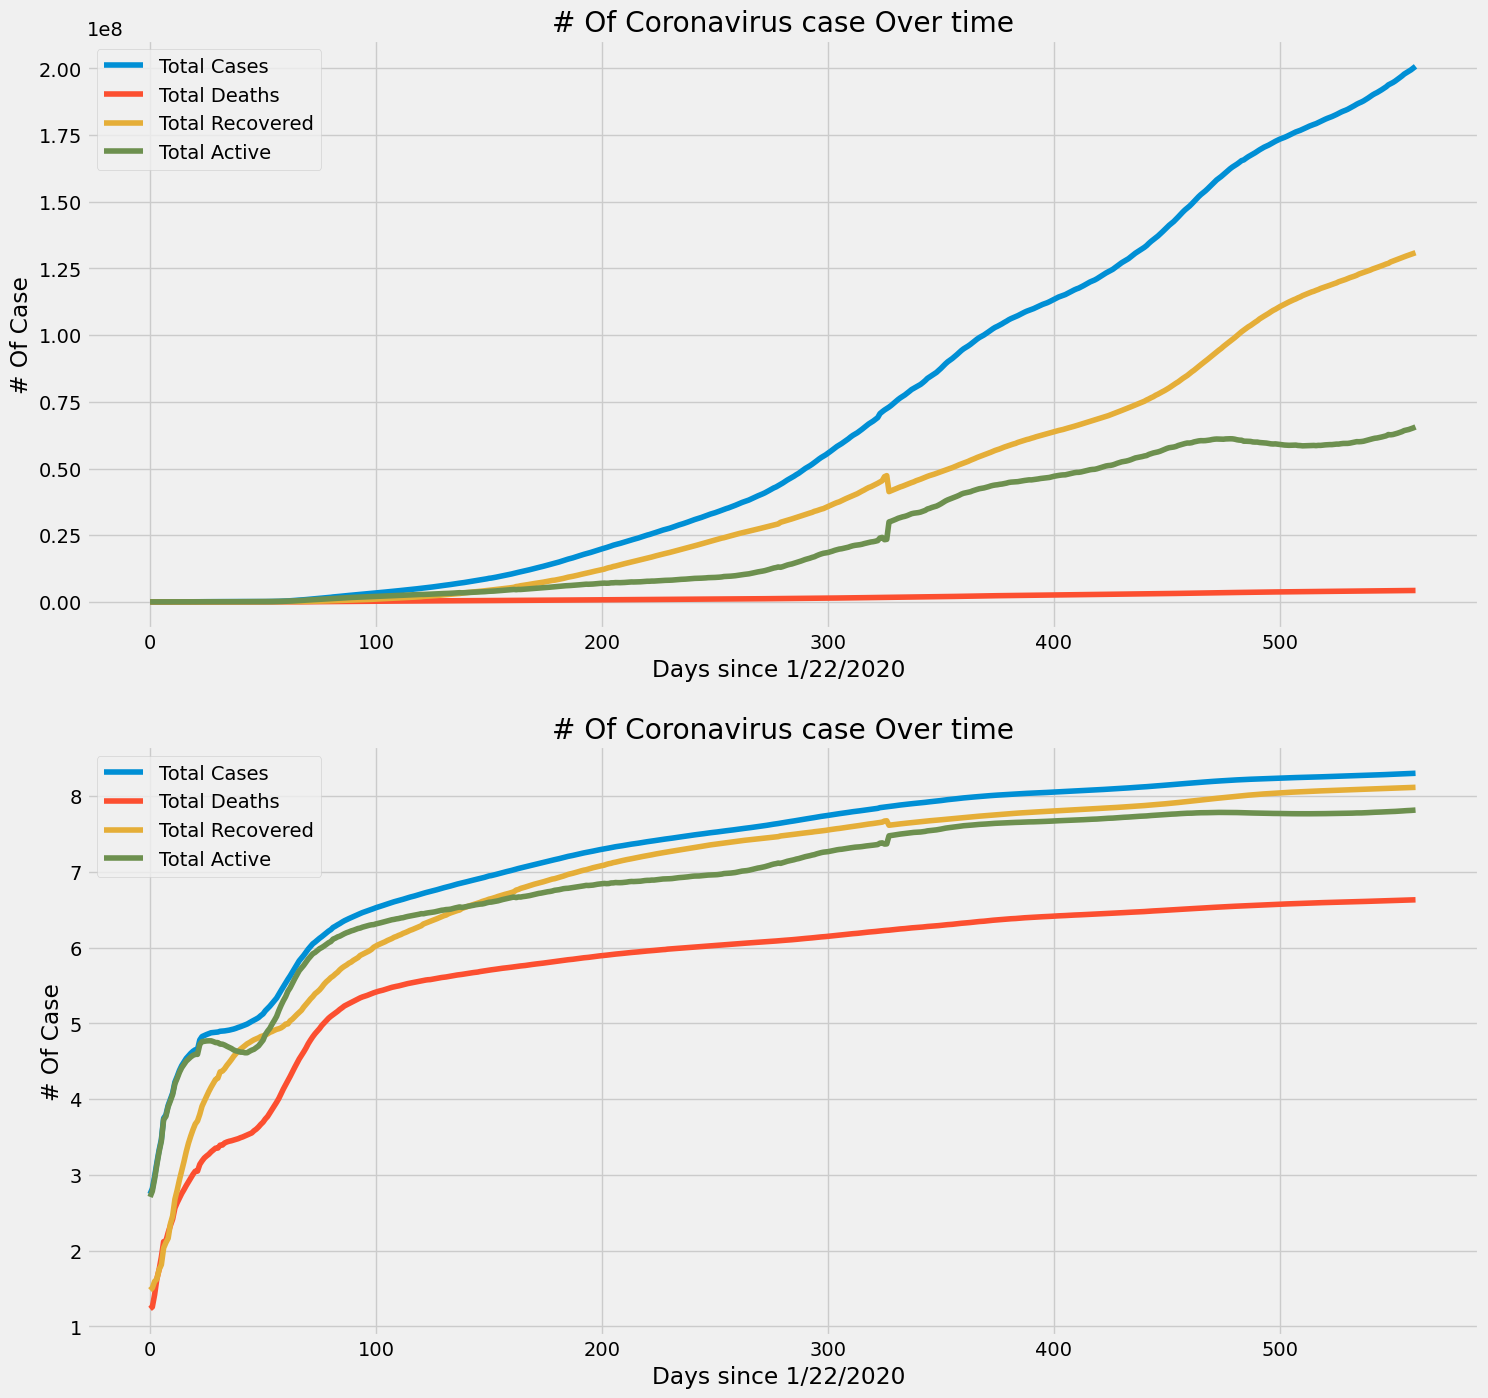

In [9]:
x= np.arange(0,len(confirmed_df.columns[4:-1])+1,1)
fig= plt.figure(figsize=(16, 16))
ax0=fig.add_subplot(2,1,1) # hình 1
ax1=fig.add_subplot(2,1,2) # hình 2
# subplot 1:Trực quan hóa số lượng 
ax0.plot(x, total_cases, label='Total Cases')
ax0.plot(x, total_deaths, label='Total Deaths')
ax0.plot(x, total_recovered, label='Total Recovered')
ax0.plot(x, total_active, label='Total Active')
ax0.legend()
ax0.set_xlabel('Days since 1/22/2020 ')
ax0.set_ylabel('# Of Case')
ax0.set_title('# Of Coronavirus case Over time')
# subplot 2: Trực quan hóa log(10) số lượng
ax1.plot(x, np.log10(total_cases), label='Total Cases')
ax1.plot(x, np.log10(total_deaths), label='Total Deaths')
ax1.plot(x, np.log10(total_recovered), label='Total Recovered')
ax1.plot(x, np.log10(total_active), label='Total Active')
ax1.legend()
ax1.set_xlabel('Days since 1/22/2020 ')
ax1.set_ylabel('# Of Case')
ax1.set_title('# Of Coronavirus case Over time')

plt.show()

## Bài toán 3
    Trực quan hóa tổng số ca bệnh, tổng số người chết, tổng số người phục hồi và tổng số đang điều trị theo thời gian (đơn vị ngày) trong 4 biểu đồ được phân tách bằng cách sử dụng biểu đồ đường.

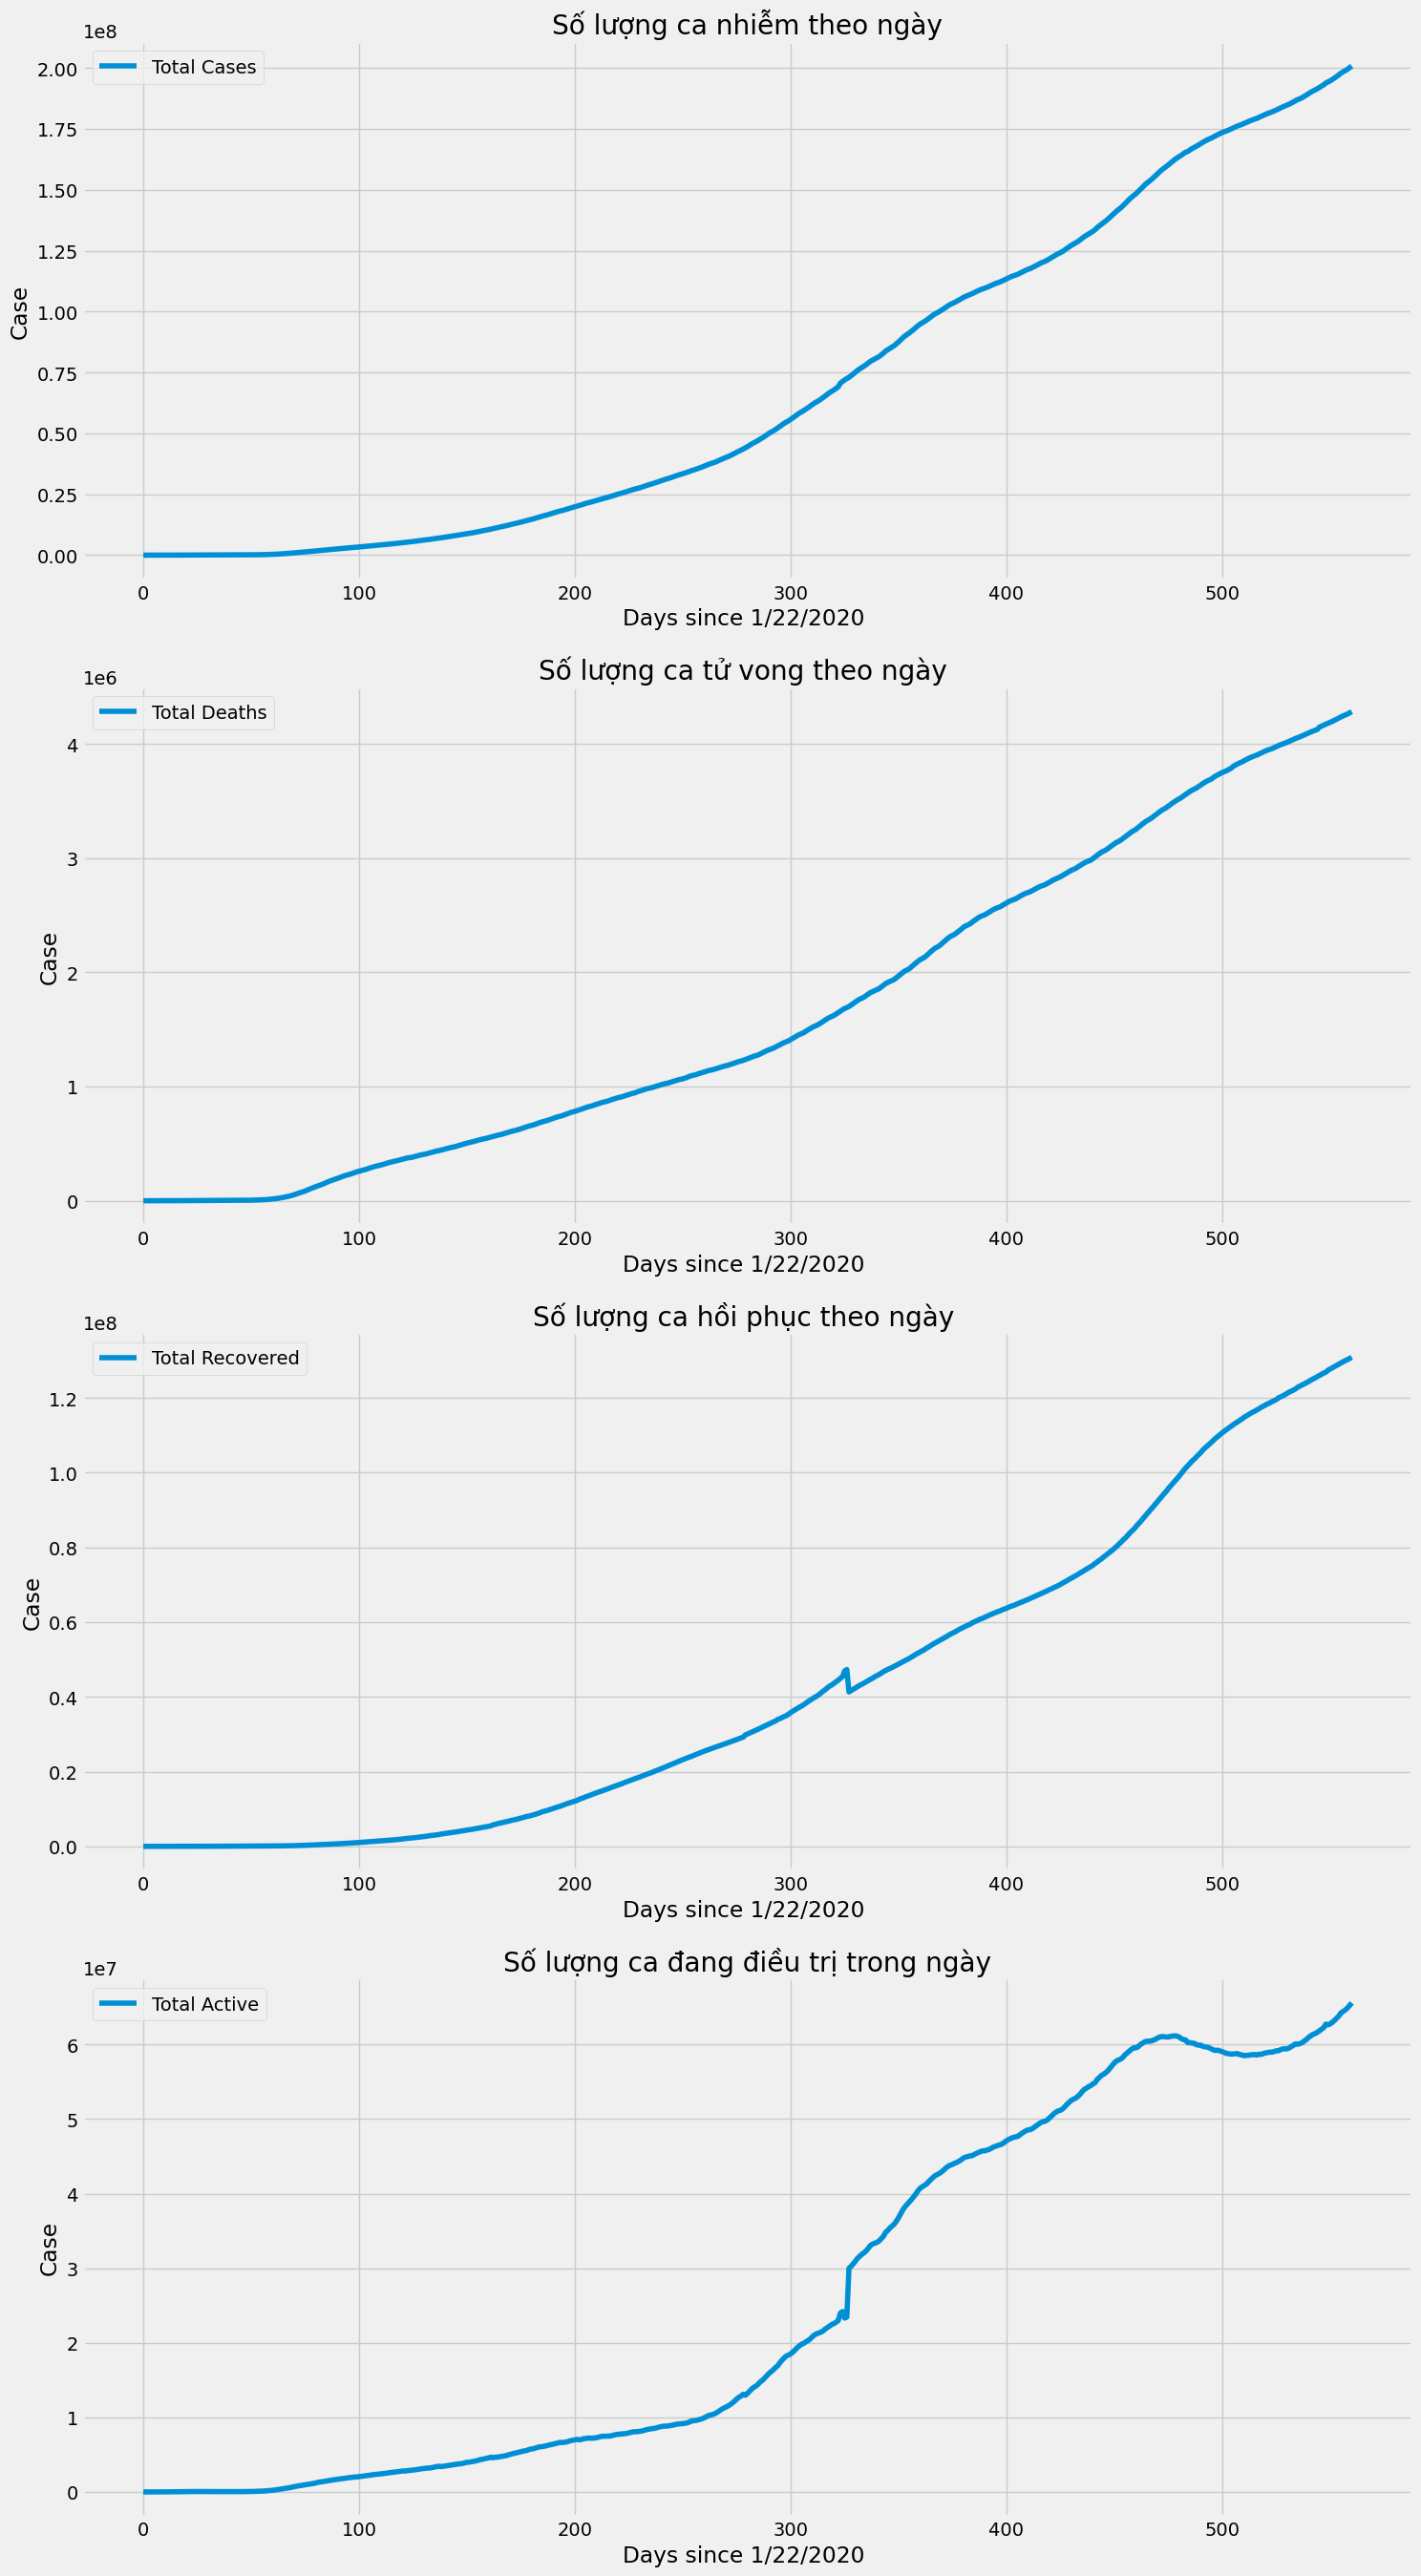

In [10]:
#Nhập mã lập trình của bạn tại đây:
x= np.arange(0,len(confirmed_df.columns[4:-1])+1,1)
fig= plt.figure(figsize=(16, 32))
ax0=fig.add_subplot(4,1,1) # hình 1
ax1=fig.add_subplot(4,1,2) # hình 2
ax2=fig.add_subplot(4,1,3) # hình 2
ax3=fig.add_subplot(4,1,4) # hình 2

# subplot 1:Trực quan hóa số lượng ca nhiễm
ax0.plot(x, total_cases, label='Total Cases')
ax0.legend()
ax0.set_xlabel('Days since 1/22/2020 ')
ax0.set_ylabel('Case')
ax0.set_title('Số lượng ca nhiễm theo ngày')

#  subplot 2:Trực quan hóa số lượng ca tử vong
ax1.plot(x, total_deaths, label='Total Deaths')
ax1.legend()
ax1.set_xlabel('Days since 1/22/2020 ')
ax1.set_ylabel('Case')
ax1.set_title('Số lượng ca tử vong theo ngày ')

# subplot 3:Trực quan hóa số lượng ca hồi phục 
ax2.plot(x, total_recovered, label='Total Recovered')
ax2.legend()
ax2.set_xlabel('Days since 1/22/2020 ')
ax2.set_ylabel('Case')
ax2.set_title('Số lượng ca hồi phục theo ngày ')

# subplot 4:Trực quan hóa số lượng ca đang điều trị
ax3.plot(x, total_active, label='Total Active')
ax3.legend()
ax3.set_xlabel('Days since 1/22/2020 ')
ax3.set_ylabel('Case')
ax3.set_title('Số lượng ca đang điều trị trong ngày')

plt.show()

## Bài toán 4
    Tính toán số lượng gia tăng hàng ngày trong tổng số trường hợp, tổng số người chết, tổng số người hồi phục và tổng số đang điều trị theo thời gian (đơn vị ngày).

In [16]:
#Nhập mã lập trình của bạn tại đây:
Rising_Number = pd.DataFrame()
Rising_Number_cases =[0,]
Rising_Number_deaths =[0,]
Rising_Number_recoveries =[0,]
Rising_Number_active =[0,]

Rising_Number_cases.extend(total_cases.iloc[1:].values-total_cases.iloc[:-1].values)
Rising_Number_deaths.extend(total_deaths.iloc[1:].values-total_deaths.iloc[:-1].values)
Rising_Number_recoveries.extend(total_recovered.iloc[1:].values-total_recovered.iloc[:-1].values) 
Rising_Number_active.extend(total_active.iloc[1:].values-total_active.iloc[:-1].values) 

Rising_Number['cases']= Rising_Number_cases 
Rising_Number['deaths']=Rising_Number_deaths 
Rising_Number['recoveries'] = Rising_Number_recoveries 
Rising_Number['active']= Rising_Number_active 

Rising_Number.index=total_cases.index
Rising_Number.to_csv('Rising_Number.csv')
print('số lượng gia tăng trong tổng số trường hợp, tổng số người chết, tổng số người hồi phục và tổng số đang điều trị theo thời gian \n ')
Rising_Number


số lượng gia tăng trong tổng số trường hợp, tổng số người chết, tổng số người hồi phục và tổng số đang điều trị theo thời gian 
 


,cases,deaths,recoveries,active
1/22/20,0,0,0,0
1/23/20,100,1,2,97
1/24/20,287,8,7,272
1/25/20,493,16,3,474
1/26/20,683,14,14,655
...,...,...,...,...
7/31/21,517345,8844,303929,204572
8/1/21,483068,7419,289178,186471
8/2/21,571103,8151,283144,279808
8/3/21,634275,10353,304468,319454


## Bài toán 5
    Trực quan hóa số lượng gia tăng hàng ngày về tổng số trường hợp, tổng số người chết, tổng số người phục hồi và tổng số đang điều trị theo thời gian (đơn vị ngày) trong 4 biểu đồ riêng biệt bằng cách sử dụng biểu đồ cột.

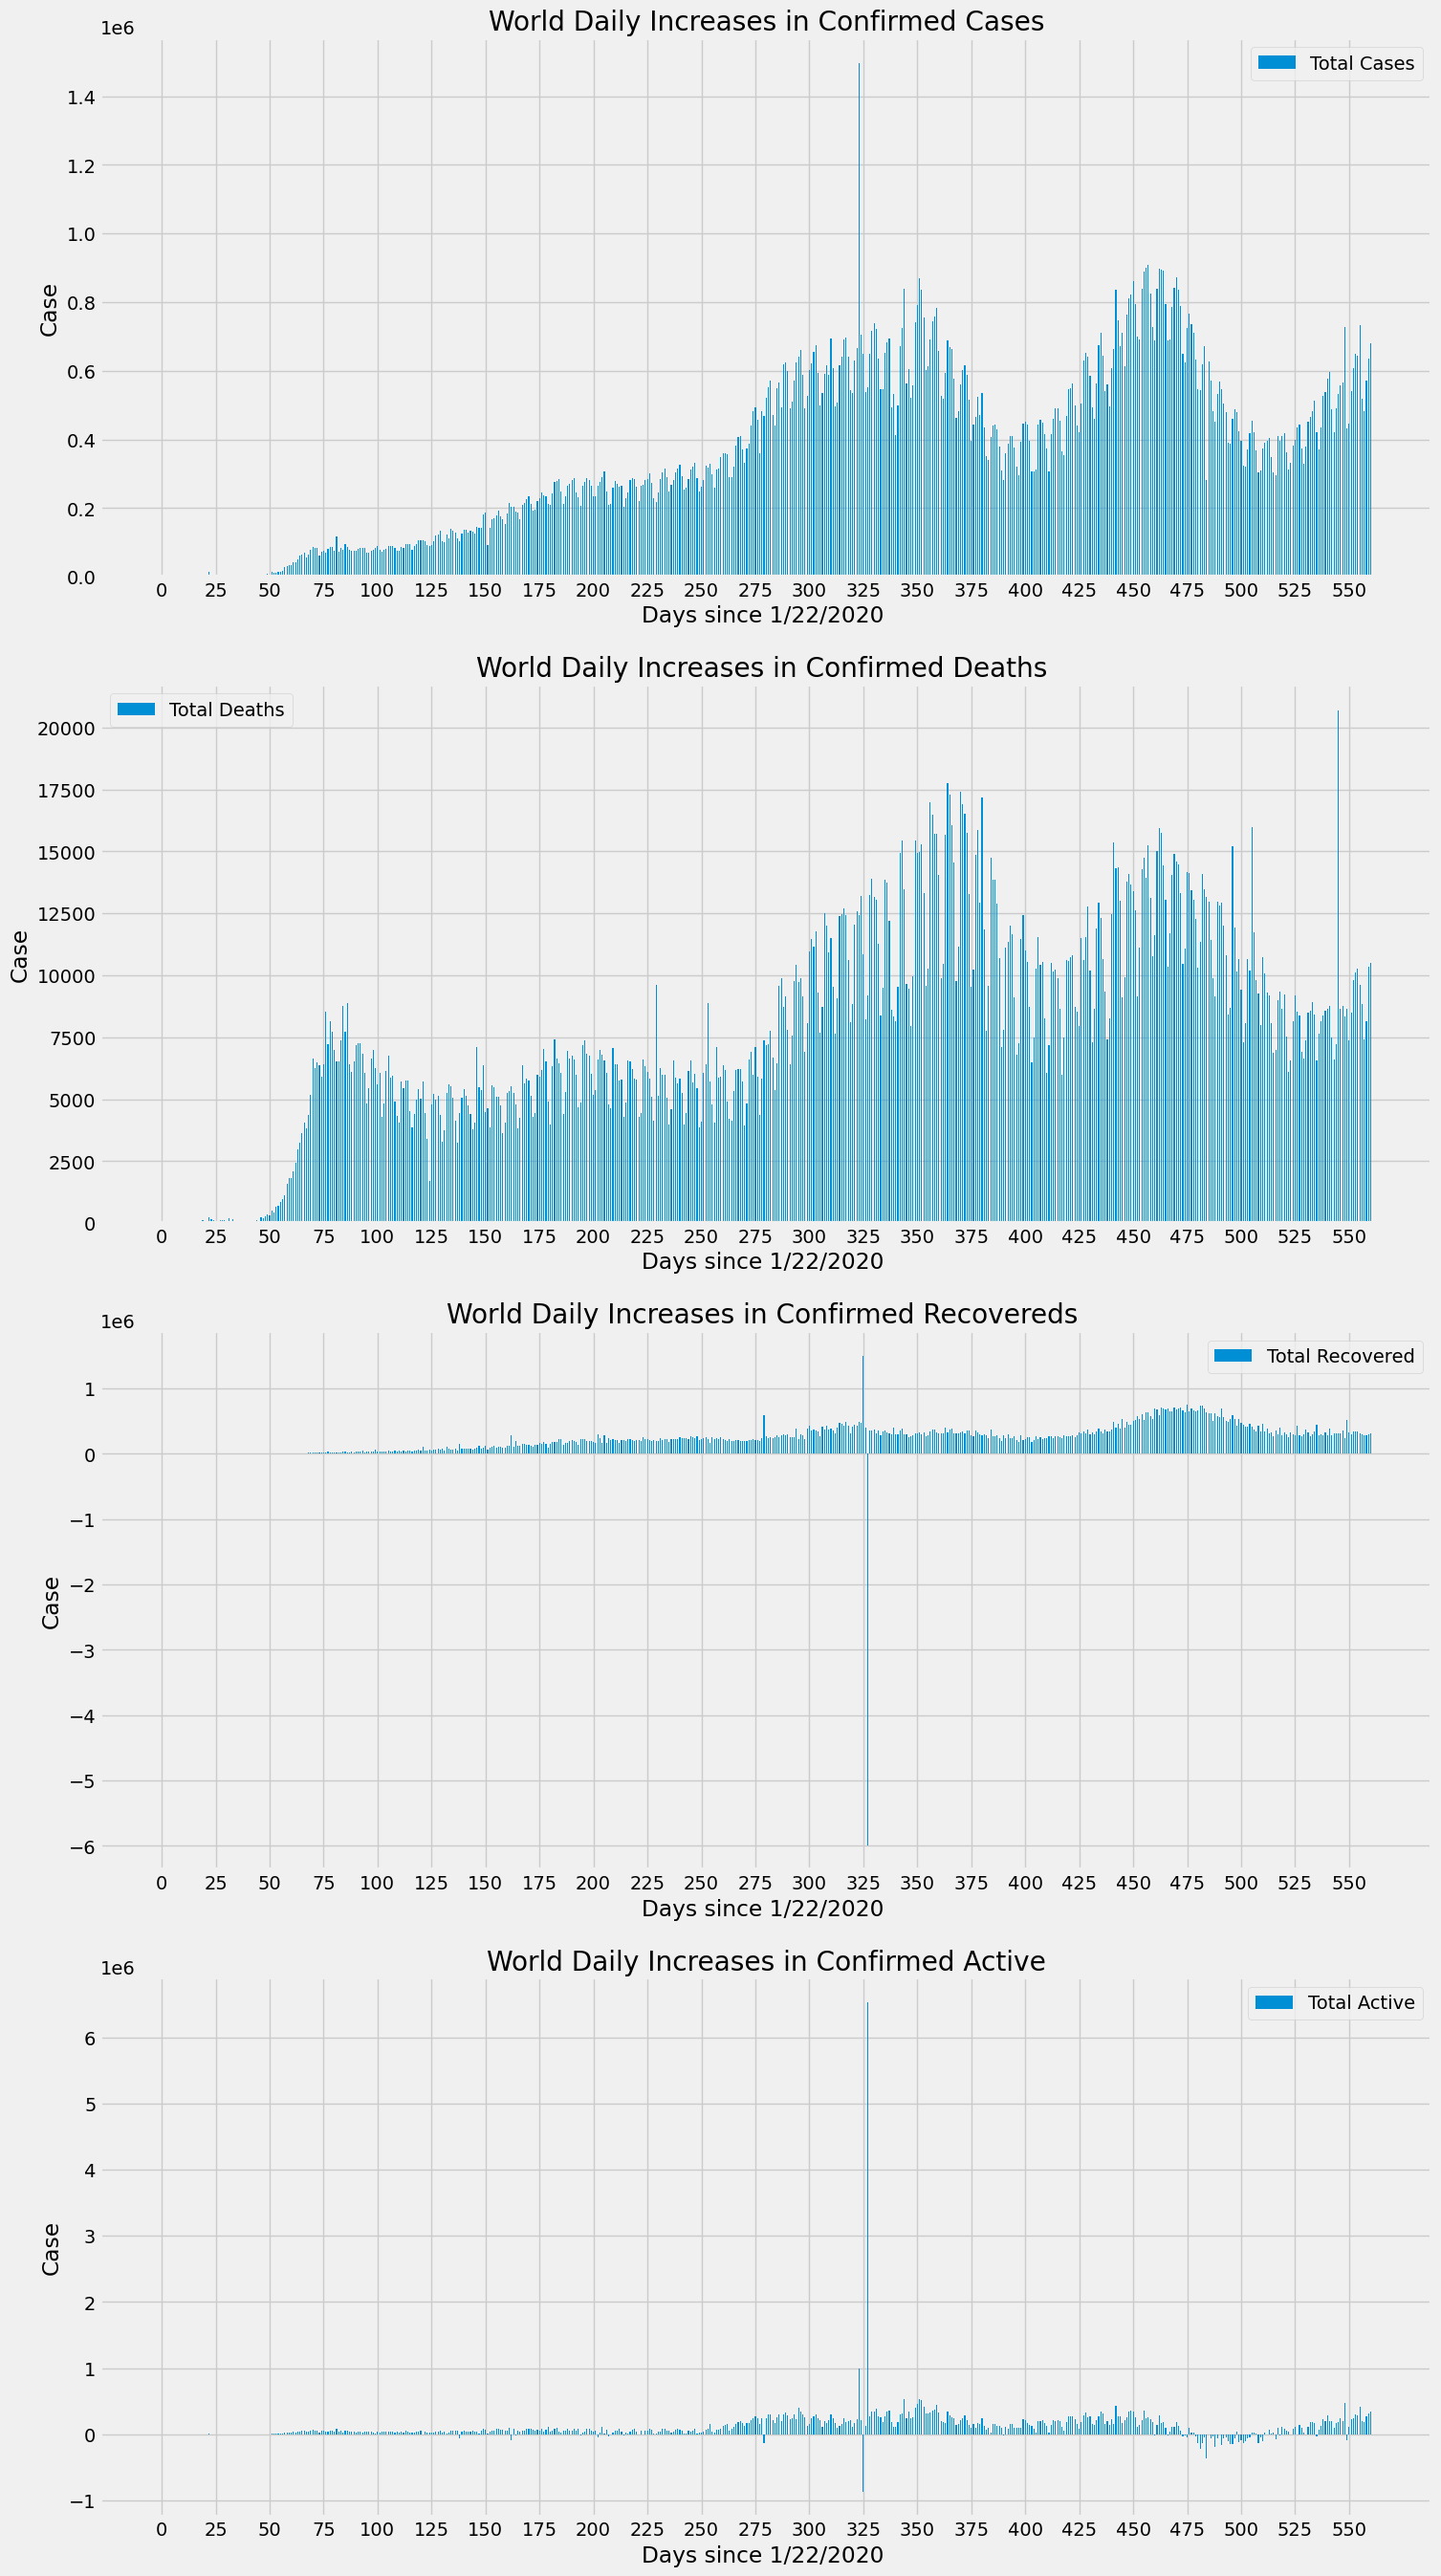

In [11]:
#Nhập mã lập trình của bạn tại đây:
x= np.arange(0,len(confirmed_df.columns[4:-1])+1,1)
fig= plt.figure(figsize=(16, 32))
ax0=fig.add_subplot(4,1,1) # hình 1
ax1=fig.add_subplot(4,1,2) # hình 2
ax2=fig.add_subplot(4,1,3) # hình 2
ax3=fig.add_subplot(4,1,4) # hình 2
# subplot 1:Trực quan hóa số lượng ca nhiễm
ax0.bar(x,Rising_Number['cases'], label='Total Cases',width=0.5)
ax0.set_xticks(np.arange(0,len(confirmed_df.columns[4:-1])+1,25)) 
ax0.legend()
ax0.set_xlabel('Days since 1/22/2020 ')
ax0.set_ylabel('Case')
ax0.set_title('World Daily Increases in Confirmed Cases')

#  subplot 2:Trực quan hóa số lượng ca tử vong
ax1.bar(x,Rising_Number['deaths'], label='Total Deaths',width=0.5)
ax1.set_xticks(np.arange(0,len(confirmed_df.columns[4:-1])+1,25)) 
ax1.legend()
ax1.set_xlabel('Days since 1/22/2020 ')
ax1.set_ylabel('Case')
ax1.set_title('World Daily Increases in Confirmed Deaths ')

# subplot 3:Trực quan hóa số lượng ca hồi phục 
ax2.bar(x, Rising_Number['recoveries'], label='Total Recovered',width=0.5)
ax2.set_xticks(np.arange(0,len(confirmed_df.columns[4:-1])+1,25)) 
ax2.legend()
ax2.set_xlabel('Days since 1/22/2020 ')
ax2.set_ylabel('Case')
ax2.set_title('World Daily Increases in Confirmed Recovereds ')

# subplot 4:Trực quan hóa số lượng ca đang điều trị
ax3.bar(x, Rising_Number['active'], label='Total Active',width=0.5)
ax3.set_xticks(np.arange(0,len(confirmed_df.columns[4:-1])+1,25)) 
ax3.legend()
ax3.set_xlabel('Days since 1/22/2020 ')
ax3.set_ylabel('Case')
ax3.set_title('World Daily Increases in Confirmed Active')

plt.show()

# Bài toán 6:
    Tính tỷ lệ tử vong toàn cầu và tỷ lệ hồi phục theo phần trăm theo thời gian.

In [13]:
#Nhập mã lập trình của bạn tại đây:
mortality_rate = (total_deaths/total_cases)*100 # tỷ lệ tử vong
recovery_rate = (total_recovered/total_cases)*100 #tỷ lệ hồi phục

# Bài toán 7
**7.1**

    Trực quan hóa tỷ lệ tử vong theo thời gian (đơn vị ngày) bằng biểu đồ đường.

    Sử dụng đường gạch ngang để trực quan hóa tỷ lệ tử vong trung bình mọi lúc.

3.438476174895814


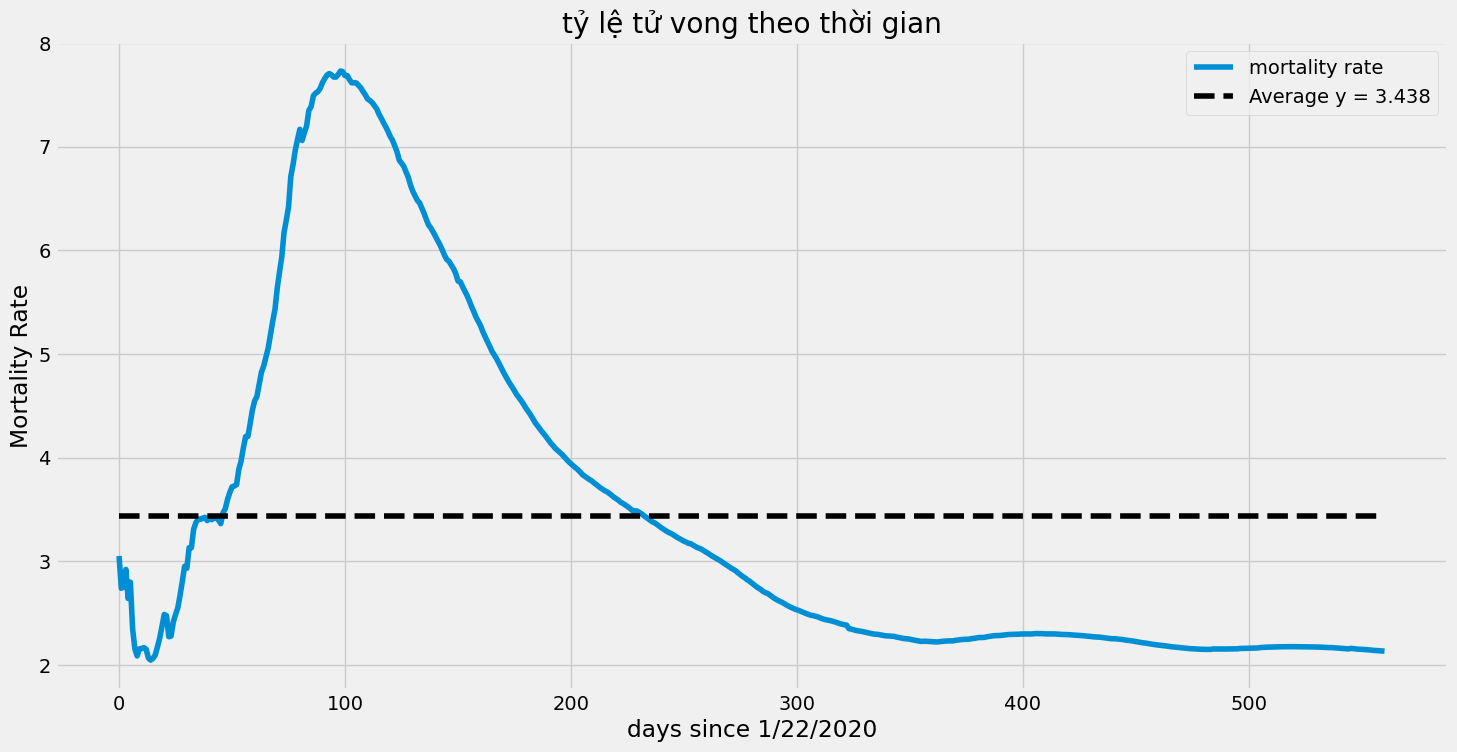

In [14]:
#Nhập mã lập trình của bạn tại đây:
Average=(mortality_rate.sum()/len(mortality_rate)) # giá trị trung bình
print(Average)
ones_list=np.array([1]*len(mortality_rate)) # mảng giá trị 1
plt.figure(figsize=(16,8))
plt.plot(x,mortality_rate,label='mortality rate')
plt.plot(x,Average*ones_list,color= 'black',linestyle='--',label='Average y = 3.438')
plt.legend()
plt.xlabel('days since 1/22/2020')
plt.ylabel('Mortality Rate')
plt.title('tỷ lệ tử vong theo thời gian')

plt.show()

**7.2**

    Trực quan hóa tỷ lệ phục hồi theo thời gian (đơn vị ngày) bằng biểu đồ đường.

    Sử dụng đường gạch ngang để trực quan hóa tỷ lệ tử vong trung bình mọi lúc.

52.71640799696072


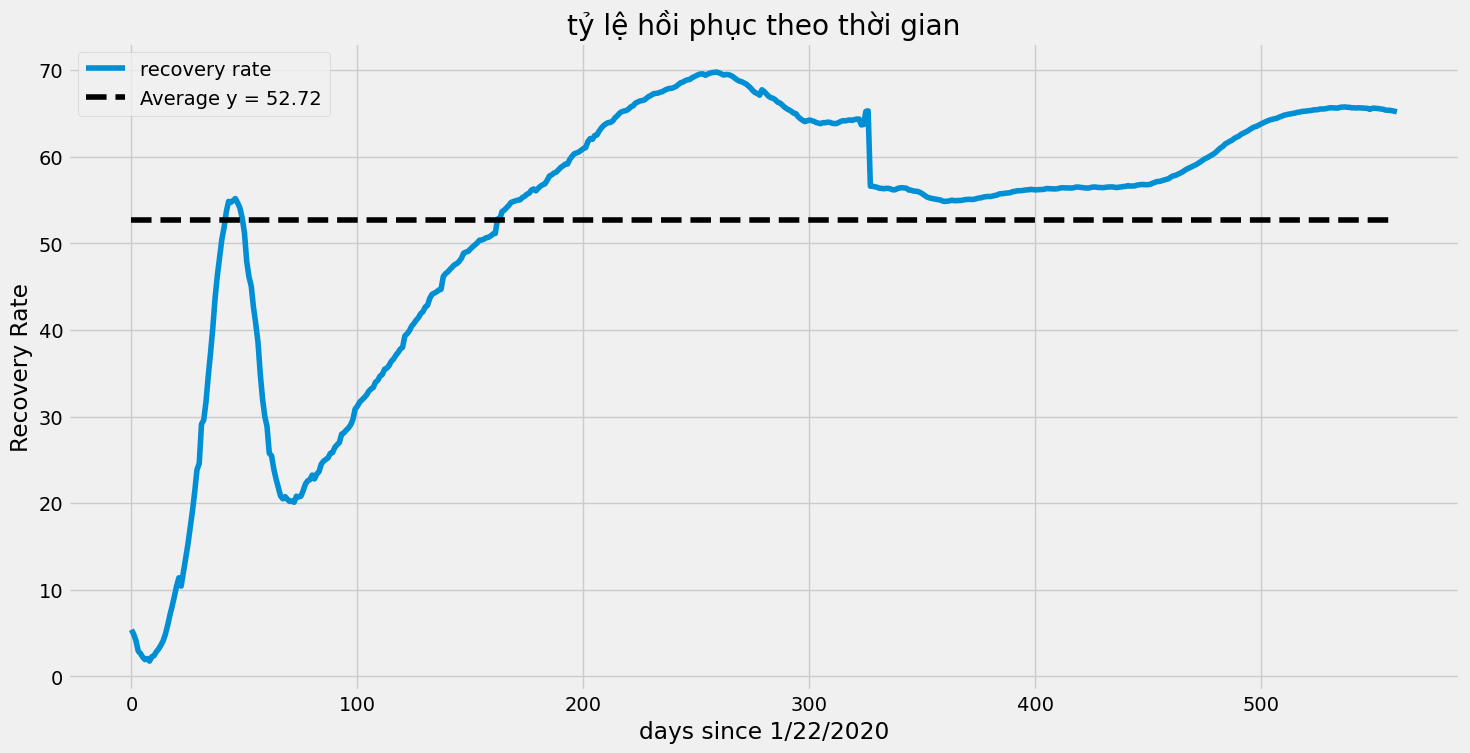

In [15]:
#Nhập mã lập trình của bạn tại đây:
Average=(recovery_rate.sum()/len(recovery_rate)) # giá trị trung bình
print(Average)
ones_list=np.array([1]*len(recovery_rate)) # mảng giá trị 1
plt.figure(figsize=(16,8))
plt.plot(x,recovery_rate,label='recovery rate')
plt.plot(x,Average*ones_list,color= 'black',linestyle='--',label='Average y = 52.72')
plt.legend()
plt.xlabel('days since 1/22/2020')
plt.ylabel('Recovery Rate')
plt.title('tỷ lệ hồi phục theo thời gian')

plt.show()

#  5. Phân tích theo lục địa

## Tiền xử lý dữ liệu

In [16]:
# Changing the conuntry names as required by pycountry_convert Lib
confirmed_df.loc[confirmed_df['Country/Region'] == "US", "Country/Region"] = "USA"
deaths_df.loc[deaths_df['Country/Region'] == "US", "Country/Region"] = "USA"
recoveries_df.loc[recoveries_df['Country/Region'] == "US", "Country/Region"] = "USA"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Korea, South', "Country/Region"] = 'South Korea'
deaths_df.loc[deaths_df['Country/Region'] == 'Korea, South', "Country/Region"] = 'South Korea'
recoveries_df.loc[recoveries_df['Country/Region'] == "Korea, South", "Country/Region"] = "South Korea"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Taiwan*', "Country/Region"] = 'Taiwan'
deaths_df.loc[deaths_df['Country/Region'] == 'Taiwan*', "Country/Region"] = 'Taiwan'
recoveries_df.loc[recoveries_df['Country/Region'] == "Taiwan*", "Country/Region"] = "Taiwan"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Congo (Kinshasa)', "Country/Region"] = 'Democratic Republic of the Congo'
deaths_df.loc[deaths_df['Country/Region'] == 'Congo (Kinshasa)', "Country/Region"] = 'Democratic Republic of the Congo'
recoveries_df.loc[recoveries_df['Country/Region'] == "Congo (Kinshasa)", "Country/Region"] = "Democratic Republic of the Congo"

confirmed_df.loc[confirmed_df['Country/Region'] == "Cote d'Ivoire", "Country/Region"] = "Côte d'Ivoire"
deaths_df.loc[deaths_df['Country/Region'] == "Cote d'Ivoire", "Country/Region"] = "Côte d'Ivoire"
recoveries_df.loc[recoveries_df['Country/Region'] == "Cote d'Ivoire", "Country/Region"] = "Côte d'Ivoire"

confirmed_df.loc[confirmed_df['Country/Region'] == "Reunion", "Country/Region"] = "Réunion"
deaths_df.loc[deaths_df['Country/Region'] == "Reunion", "Country/Region"] = "Réunion"
recoveries_df.loc[recoveries_df['Country/Region'] == "Reunion", "Country/Region"] = "Réunion"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Congo (Brazzaville)', "Country/Region"] = 'Republic of the Congo'
deaths_df.loc[deaths_df['Country/Region'] == 'Congo (Brazzaville)', "Country/Region"] = 'Republic of the Congo'
recoveries_df.loc[recoveries_df['Country/Region'] == "Congo (Brazzaville)", "Country/Region"] = "Republic of the Congo"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Bahamas, The', "Country/Region"] = 'Bahamas'
deaths_df.loc[deaths_df['Country/Region'] == 'Bahamas, The', "Country/Region"] = 'Bahamas'
recoveries_df.loc[recoveries_df['Country/Region'] == "Bahamas, The", "Country/Region"] = "Bahamas"

confirmed_df.loc[confirmed_df['Country/Region'] == 'Gambia, The', "Country/Region"] = 'Gambia'
deaths_df.loc[deaths_df['Country/Region'] == 'Gambia, The', "Country/Region"] = 'Gambia'
recoveries_df.loc[recoveries_df['Country/Region'] == "Gambia, The", "Country/Region"] = "Gambia"

# getting all countries
countries = np.asarray(confirmed_df["Country/Region"])
countries1 = np.asarray(deaths_df["Country/Region"])
countries2 = np.asarray(recoveries_df["Country/Region"])

# Continent_code to Continent_names
continents = {
    'NA': 'North America',
    'SA': 'South America',
    'AS': 'Asia',
    'OC': 'Australia',
    'AF': 'Africa',
    'EU' : 'Europe',
    'na' : 'Others'
}

# Defininng Function for getting continent code for country.
def country_to_continent_code(country):
    try:
        return pc.country_alpha2_to_continent_code(pc.country_name_to_country_alpha2(country))
    except :
        return 'na'

# hàm xuất tên lục địa
def con_word(x):
    continents = {'NA': 'North America',
                  'SA': 'South America',
                  'AS': 'Asia',
                  'OC': 'Australia',
                  'AF': 'Africa',
                  'EU' : 'Europe',
                  'na' : 'Others'}
    return continents[x]


# Bài toán 8
    Thêm trường "continent" vào tập dữ liệu confirm_df, death_df và recorveries_df:

In [17]:
#Nhập mã lập trình của bạn tại đây:
confirmed_df.insert(2,'continent',(confirmed_df['Country/Region'].apply(country_to_continent_code)).apply(con_word))
deaths_df.insert(2,'continent',(deaths_df['Country/Region'].apply(country_to_continent_code)).apply(con_word))
recoveries_df.insert(2,'continent',(recoveries_df['Country/Region'].apply(country_to_continent_code)).apply(con_word))


In [18]:
confirmed_df.head()

,Province/State,Country/Region,continent,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,Asia,33.93911,67.709953,0,0,0,0,0,...,144285,145008,145552,145996,146523,147154,147501,147985,148572,148933
1,NaN,Albania,Europe,41.15330,20.168300,0,0,0,0,0,...,132891,132922,132952,132999,133036,133081,133121,133146,133211,133310
2,NaN,Algeria,Africa,28.03390,1.659600,0,0,0,0,0,...,163660,165204,167131,168668,170189,171392,172564,173922,175229,176724
3,NaN,Andorra,Europe,42.50630,1.521800,0,0,0,0,0,...,14577,14586,14586,14655,14678,14678,14678,14747,14766,14797
4,NaN,Angola,Africa,-11.20270,17.873900,0,0,0,0,0,...,41879,42110,42288,42486,42646,42777,42815,42970,43070,43158


In [19]:
deaths_df.head()

,Province/State,Country/Region,continent,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,Asia,33.93911,67.709953,0,0,0,0,0,...,6477,6515,6577,6615,6677,6708,6737,6774,6804,6836
1,NaN,Albania,Europe,41.15330,20.168300,0,0,0,0,0,...,2456,2456,2457,2457,2457,2457,2457,2457,2457,2457
2,NaN,Algeria,Africa,28.03390,1.659600,0,0,0,0,0,...,4087,4112,4161,4189,4219,4254,4291,4329,4370,4404
3,NaN,Andorra,Europe,42.50630,1.521800,0,0,0,0,0,...,127,127,127,127,128,128,128,128,128,128
4,NaN,Angola,Africa,-11.20270,17.873900,0,0,0,0,0,...,991,994,1000,1003,1008,1011,1016,1018,1022,1026


In [20]:
recoveries_df.head()

,Province/State,Country/Region,continent,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,...,7/26/21,7/27/21,7/28/21,7/29/21,7/30/21,7/31/21,8/1/21,8/2/21,8/3/21,8/4/21
0,NaN,Afghanistan,Asia,33.93911,67.709953,0,0,0,0,0,...,82586,82586,82586,82586,82586,82586,82586,82586,82586,82586
1,NaN,Albania,Europe,41.15330,20.168300,0,0,0,0,0,...,130152,130166,130174,130187,130205,130222,130243,130256,130291,130314
2,NaN,Algeria,Africa,28.03390,1.659600,0,0,0,0,0,...,111322,112050,112900,113707,114531,115276,116009,116770,117557,118409
3,NaN,Andorra,Europe,42.50630,1.521800,0,0,0,0,0,...,14077,14113,14113,14180,14210,14210,14210,14296,14348,14380
4,NaN,Angola,Africa,-11.20270,17.873900,0,0,0,0,0,...,35686,35742,35964,36025,36708,37255,37397,38360,39389,39582


# Bài toán 9
    Tạo khung dữ liệu country_df với chỉ mục là trường "Country/Region".
    Các thông tin cột này sẽ là:
    - continent: Lục địa của quốc gia.
    - Deaths: Tổng số ca dương tính.
    - Deaths: Tổng số người chết.
    - Recoveries: Tổng số ca hồi phục
    - Active: Tổng số đang điều trị.
    - Mortality Rate: Tỉ lệ tử vong tính theo phần trăm.

In [21]:
#Nhập mã lập trình của bạn tại đây:
country_df=confirmed_df.loc[:,['Country/Region','continent']].groupby('Country/Region').first()
country_df['Confirmed'] = confirmed_df.groupby('Country/Region').sum().iloc[:,[-1]]
country_df['Deaths'] =deaths_df.groupby('Country/Region').sum().iloc[:,[-1]]
country_df['Recoveries']= recoveries_df.groupby('Country/Region').sum().iloc[:,[-1]]
country_df['Active'] =country_df['Confirmed']-country_df['Deaths']-country_df['Recoveries']
country_df['Mortality Rate']=(country_df['Deaths']/country_df['Confirmed'])*100
country_df.head()

,continent,Confirmed,Deaths,Recoveries,Active,Mortality Rate
Country/Region,,,,,,
Afghanistan,Asia,148933,6836,82586,59511,4.589983
Albania,Europe,133310,2457,130314,539,1.843073
Algeria,Africa,176724,4404,118409,53911,2.492021
Andorra,Europe,14797,128,14380,289,0.865040
Angola,Africa,43158,1026,39582,2550,2.377311


# Bài toán 10
    Tạo khung dữ liệu Continental_df với chỉ mục là trường "continent".
    Các thông tin cột này sẽ là:

     - Confirmed: Đất nước lục địa.
     - Deaths: Tổng số người chết.
     - Recoveries: Tổng số lần khôi phục.
     - Active: Tổng số đang điều trị.
     - Mortality Rate: Tỷ lệ tử vong tính theo phần trăm.

In [22]:
#Nhập mã lập trình của bạn tại đây:
continental_df = confirmed_df.loc[:,['continent']].groupby('continent').sum()
continental_df['Confirmed'] = confirmed_df.groupby('continent').sum().iloc[:,[-1]]
continental_df['Deaths'] = deaths_df.groupby('continent').sum().iloc[:,[-1]]
continental_df['Recoveries']= recoveries_df.groupby('continent').sum().iloc[:,[-1]]
continental_df['Active'] = continental_df['Confirmed']-continental_df['Deaths']-continental_df['Recoveries']
continental_df['Mortality Rate'] = (continental_df['Deaths']/continental_df['Confirmed'])*100
continental_df

,Confirmed,Deaths,Recoveries,Active,Mortality Rate
continent,,,,,
Africa,6855602,174000,5955131,726471,2.538070
Asia,62536726,902952,57853343,3780431,1.443875
Australia,90000,1425,55290,33285,1.583333
Europe,52448545,1167140,27947075,23334330,2.225305
North America,42351963,924518,5776939,35650506,2.182940
Others,753558,16614,654615,82329,2.204741
South America,35722194,1096367,32656668,1969159,3.069148


## Biểu đồ đường mẫu
Dưới đây là các hàm mẫu để trực quan hóa các trường hợp sinh động theo thời gian ở mỗi châu lục / quốc gia:

In [23]:
def plot_params(ax,axis_label= None, plt_title = None,label_size=15, axis_fsize = 15, title_fsize = 20, scale = 'linear' ):
    # Tick-Parameters
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which='both', width=1,labelsize=label_size)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3, color='0.8')

    # Grid
    plt.grid(lw = 1, ls = '-', c = "0.7", which = 'major')
    plt.grid(lw = 1, ls = '-', c = "0.9", which = 'minor')

    # Plot Title    
    plt.title( plt_title,{'fontsize':title_fsize})

    # Yaxis sacle
    plt.yscale(scale)
    plt.minorticks_on()
    # Plot Axes Labels
    xl = plt.xlabel(axis_label[0],fontsize = axis_fsize)
    yl = plt.ylabel(axis_label[1],fontsize = axis_fsize)

def visualize_covid_cases(confirmed, deaths,
                          continent=None , country = None , state = None, period = None, figure = None,
                          scale = "linear"):
    x = 0
    if figure == None:
        f = plt.figure(figsize=(10,10))
        # Sub plot
        ax = f.add_subplot(111)
    else :
        f = figure[0]
        # Sub plot
        ax = f.add_subplot(figure[1],figure[2],figure[3])
    ax.set_axisbelow(True)
    plt.tight_layout(pad=10, w_pad=5, h_pad=5)

    stats = [confirmed, deaths]
    label = ["Confirmed", "Deaths"]
    if continent != None:
        params = ["continent",continent]
    elif country != None:
        params = ["country",country]
    else:
        params = ["All", "All"]
    color = ["blue","red","green"]
    marker_style = dict(linewidth=3, linestyle='-', marker='o',markersize=4, markerfacecolor='#ffffff')
    for i,stat in enumerate(stats):
        if params[1] == "All" :
            cases = np.sum(np.asarray(stat.iloc[:,5:]),axis = 0)[x:]
        else:
            cases = np.sum(np.asarray(stat[stat[params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        date = np.arange(1,cases.shape[0]+1)[x:]
        plt.plot(date,cases,label = label[i]+" (Total : "+str(cases[-1])+")",color=color[i],**marker_style)
        plt.fill_between(date,cases,color=color[i],alpha=0.3)
    if params[1] == "All" :
        Total_confirmed = np.sum(np.asarray(stats[0].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1].iloc[:,5:]),axis = 0)[x:]
    else :
        Total_confirmed =  np.sum(np.asarray(stats[0][stats[0][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1][stats[1][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]

    text = stats[0].columns[5]+" to "+stats[0].columns[-1]+"\n"
    text += "Mortality rate : "+ str(int(Total_deaths[-1]/(Total_confirmed[-1])*10000)/100)+"\n"
    text += "Last 5 Days:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-6])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-6])+"\n"
    text += "Last 24 Hours:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-2])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-2])+"\n"

    plt.text(0.02, 0.78, text, fontsize=15, horizontalalignment='left',
             verticalalignment='top', transform=ax.transAxes,bbox=dict(facecolor='white', alpha=0.4))

    # Plot Axes Labels
    axis_label = ["Days ("+confirmed_df.columns[5]+" - "+confirmed_df.columns[-1]+")","No of Cases"]

    # Plot Parameters
    plot_params(ax,axis_label,scale = scale)

    # Plot Title
    if params[1] == "All" :
        plt.title("COVID-19 Cases World",{'fontsize':25})
    else:
        plt.title("COVID-19: "+params[1] ,{'fontsize':25})

    # Legend Location
    l = plt.legend(loc= "best",fontsize = 15)

    if figure == None:
        plt.show()



# Bài toán 11
**11.1**

  Áp dụng hàm visual_covid_case để hiển thị trực quan hóa về Covid của 7 lục địa trong 7 biểu đồ đường được riêng biệt. Thứ tự hiển thị được sắp xếp theo thứ tự giảm dần theo số ca được xác nhận.
    

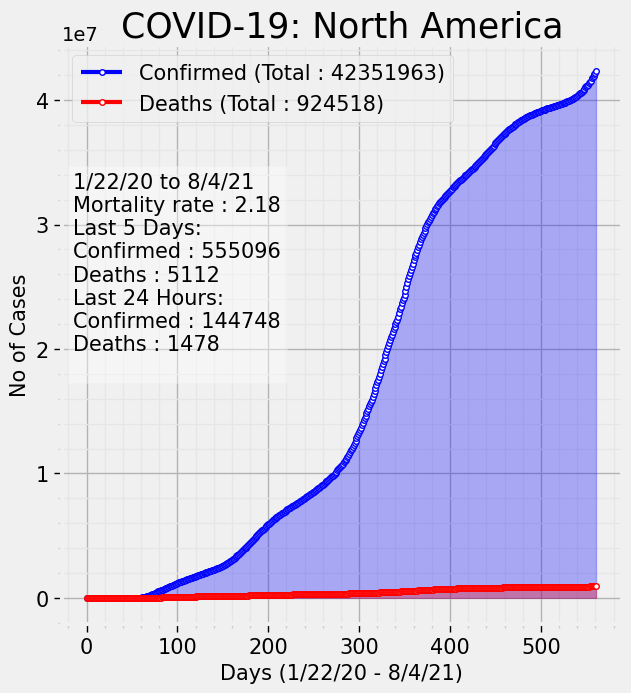

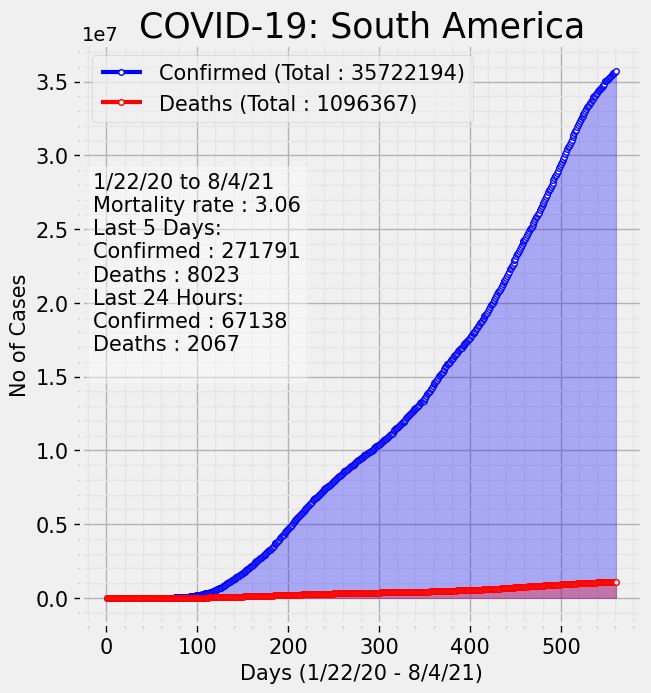

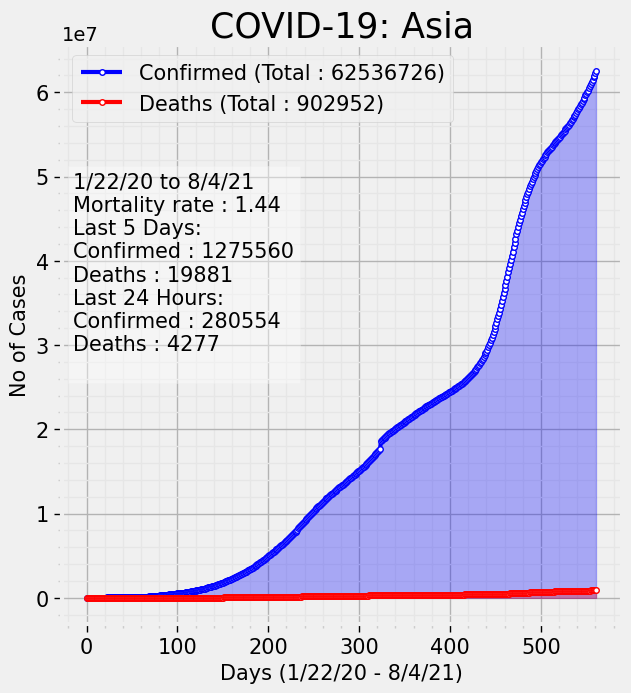

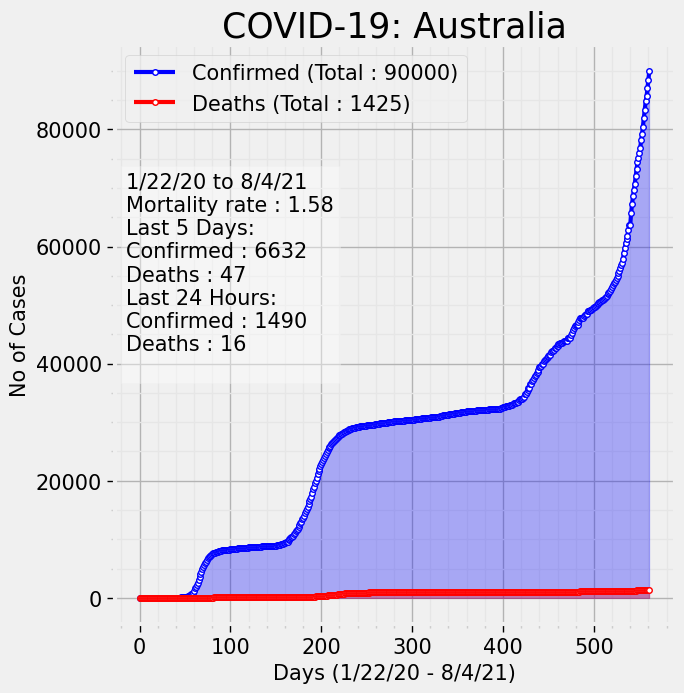

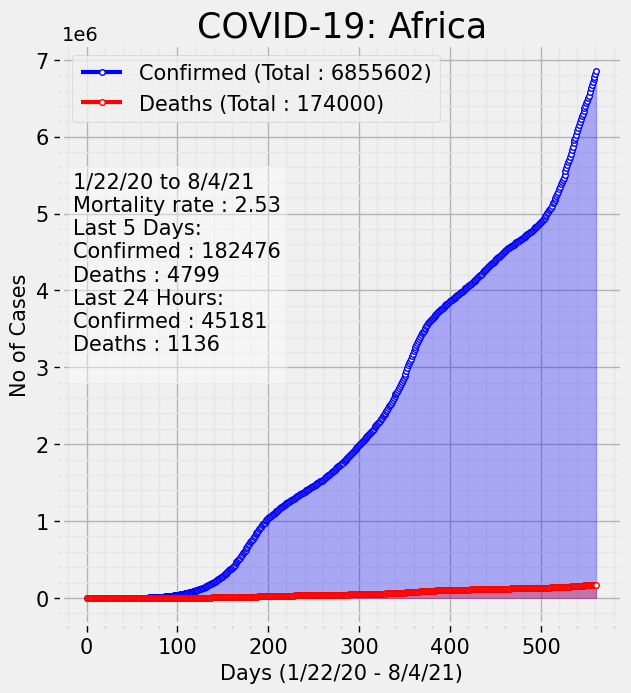

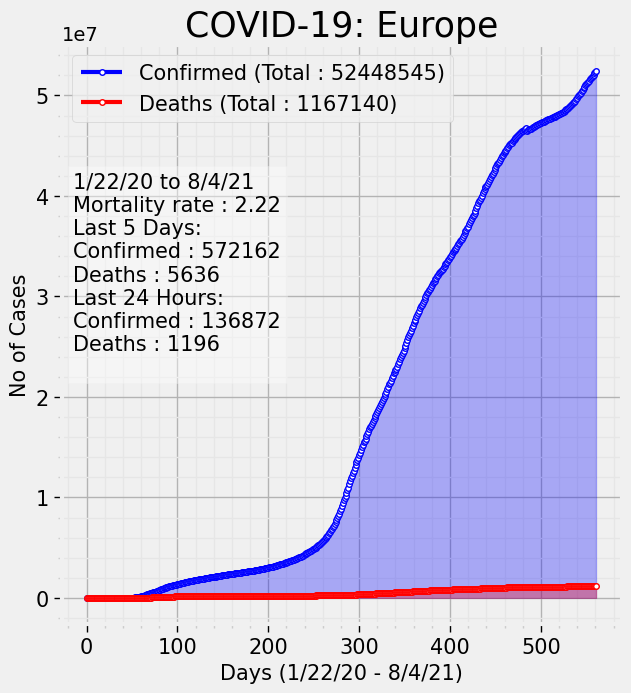

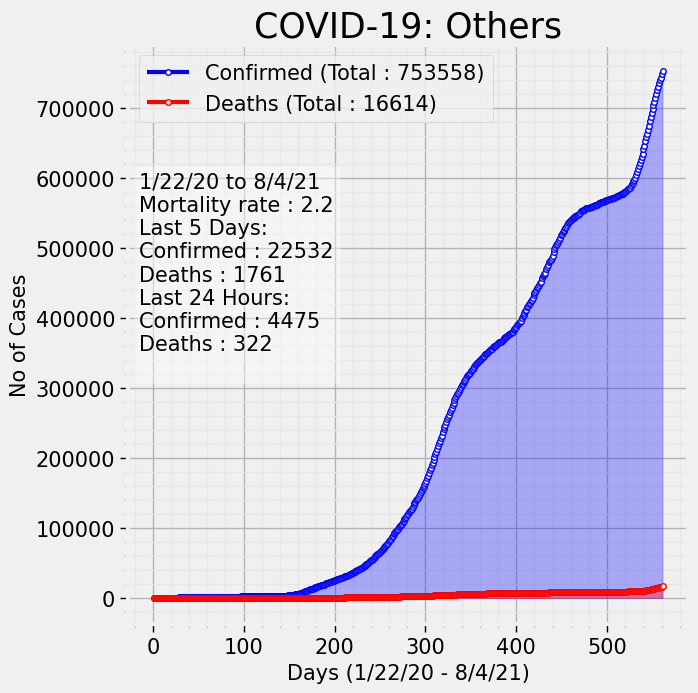

In [24]:
#Nhập mã lập trình của bạn tại đây:
for x in continents.values():
    visualize_covid_cases(confirmed_df,deaths_df,continent=x)



**11.2**

    Sử đổi "plot_params" và hàm "visualize_covid_cases" để:
    - Hiển thị kết quả của 7 ngày gần nhất thay vì 5 ngày.
     - Thêm "Recoveries line" vào biểu đồ chính.
     - Thêm số "Total Recoveries" vào bảng nhỏ.
     - Thêm "Recoveries" được nộp trong 7 ngày và 24 giờ qua vào menu thông tin.

In [31]:
#Nhập mã lập trình của bạn tại đây:
def plot_params(ax,axis_label= None, plt_title = None,label_size=15, axis_fsize = 15, title_fsize = 20, scale = 'linear' ):
    # Tick-Parameters
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(which='both', width=1,labelsize=label_size)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3, color='0.8')

    # Grid
    plt.grid(lw = 1, ls = '-', c = "0.7", which = 'major')
    plt.grid(lw = 1, ls = '-', c = "0.9", which = 'minor')

    # Plot Title    
    plt.title( plt_title,{'fontsize':title_fsize})

    # Yaxis sacle
    plt.yscale(scale)
    plt.minorticks_on()
    # Plot Axes Labels
    xl = plt.xlabel(axis_label[0],fontsize = axis_fsize)
    yl = plt.ylabel(axis_label[1],fontsize = axis_fsize)

def visualize_covid_cases_2(confirmed, deaths, recoveries,
                          continent=None , country = None , state = None, period = None, figure = None,
                          scale = "linear"):
    x = 0
    if figure == None:
        f = plt.figure(figsize=(10,10))
        # Sub plot
        ax = f.add_subplot(111)
    else :
        f = figure[0]
        # Sub plot
        ax = f.add_subplot(figure[1],figure[2],figure[3])
    ax.set_axisbelow(True)
    plt.tight_layout(pad=10, w_pad=5, h_pad=5)

    stats = [confirmed, deaths, recoveries]
    label = ["Confirmed", "Deaths","Recoveries"]
    if continent != None:
        params = ["continent",continent]
    elif country != None:
        params = ["country",country]
    else:
        params = ["All", "All"]
    color = ["blue","red","green",'yellow']
    marker_style = dict(linewidth=3, linestyle='-', marker='o',markersize=4, markerfacecolor='#ffffff')
    for i,stat in enumerate(stats):
        if params[1] == "All" :
            cases = np.sum(np.asarray(stat.iloc[:,5:]),axis = 0)[x:]
        else:
            cases = np.sum(np.asarray(stat[stat[params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        date = np.arange(1,cases.shape[0]+1)[x:]
        plt.plot(date,cases,label = label[i]+" (Total : "+str(cases[-1])+")",color=color[i],**marker_style)
        plt.fill_between(date,cases,color=color[i],alpha=0.3)
    if params[1] == "All" :
        Total_confirmed = np.sum(np.asarray(stats[0].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1].iloc[:,5:]),axis = 0)[x:]
        Total_recoveries = np.sum(np.asarray(stats[2].iloc[:,5:]),axis = 0)[x:]
    else :
        Total_confirmed =  np.sum(np.asarray(stats[0][stats[0][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        Total_deaths = np.sum(np.asarray(stats[1][stats[1][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]
        Total_recoveries = np.sum(np.asarray(stats[2][stats[2][params[0]] == params[1]].iloc[:,5:]),axis = 0)[x:]

    text = stats[0].columns[5]+" to "+stats[0].columns[-1]+"\n"
    text += "Mortality rate : "+ str(int(Total_deaths[-1]/(Total_confirmed[-1])*10000)/100)+"\n"
    text += "Last 5 Days:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-6])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-6])+"\n"
    text += "recoveries: " + str(Total_recoveries[-1] - Total_recoveries[-6])+"\n"
    text += "Last 24 Hours:\n"
    text += "Confirmed : " + str(Total_confirmed[-1] - Total_confirmed[-2])+"\n"
    text += "Deaths : " + str(Total_deaths[-1] - Total_deaths[-2])+"\n"
    text += "recoveries: " + str(Total_recoveries[-1] - Total_recoveries[-2])+"\n"


    plt.text(0.02, 0.78, text, fontsize=15, horizontalalignment='left',
             verticalalignment='top', transform=ax.transAxes,bbox=dict(facecolor='white', alpha=0.4))

    # Plot Axes Labels
    axis_label = ["Days ("+confirmed_df.columns[5]+" - "+confirmed_df.columns[-1]+")","No of Cases"]

    # Plot Parameters
    plot_params(ax,axis_label,scale = scale)

    # Plot Title
    if params[1] == "All" :
        plt.title("COVID-19 Cases World",{'fontsize':25})
    else:
        plt.title("COVID-19: "+params[1] ,{'fontsize':25})

    # Legend Location
    l = plt.legend(loc= "best",fontsize = 15)

    if figure == None:
        plt.show()



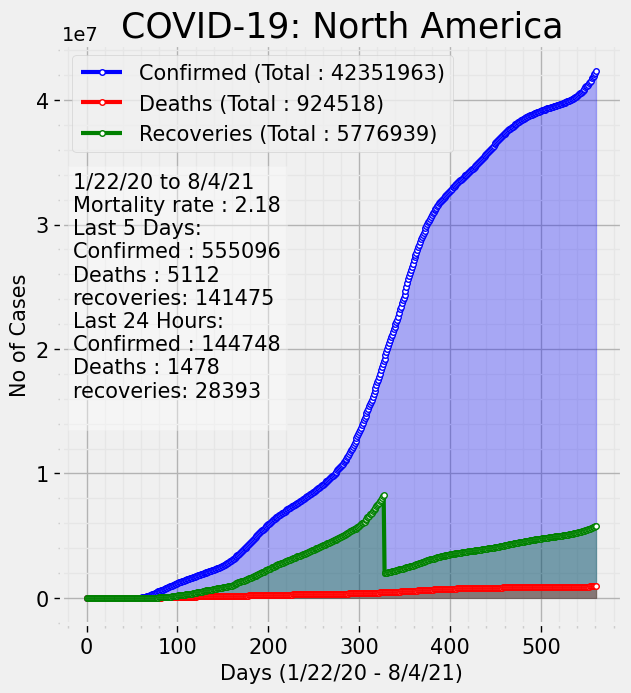

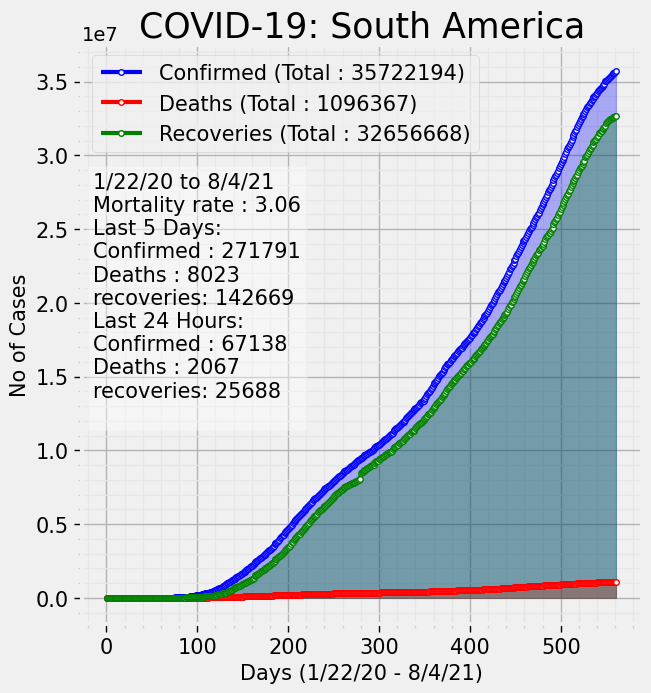

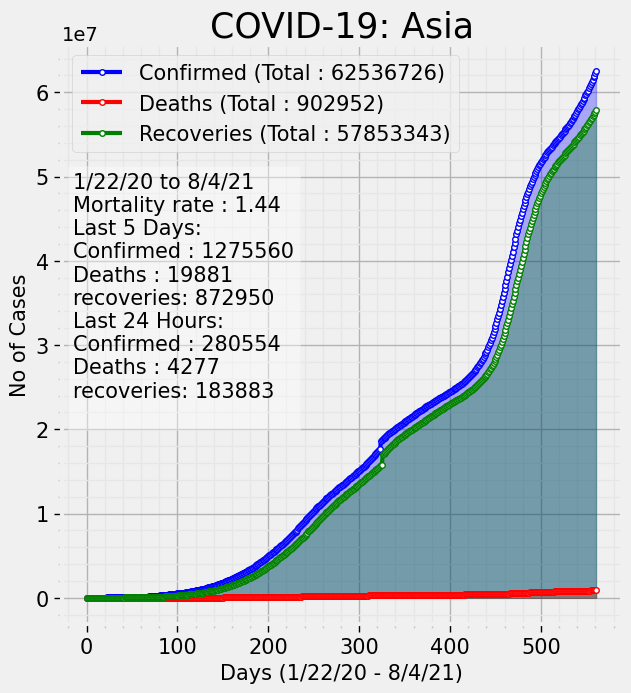

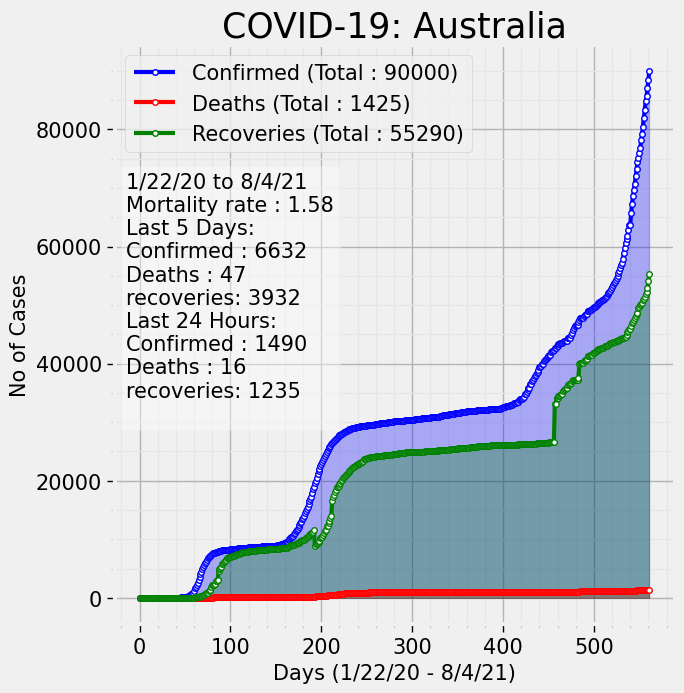

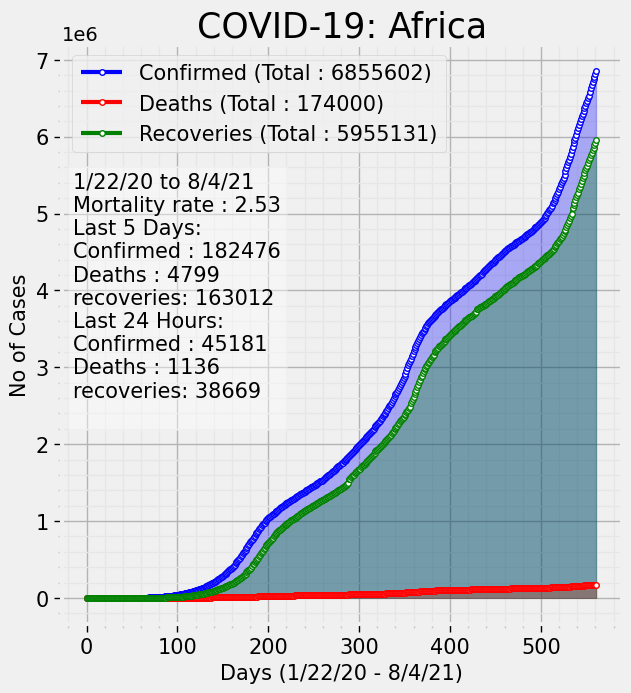

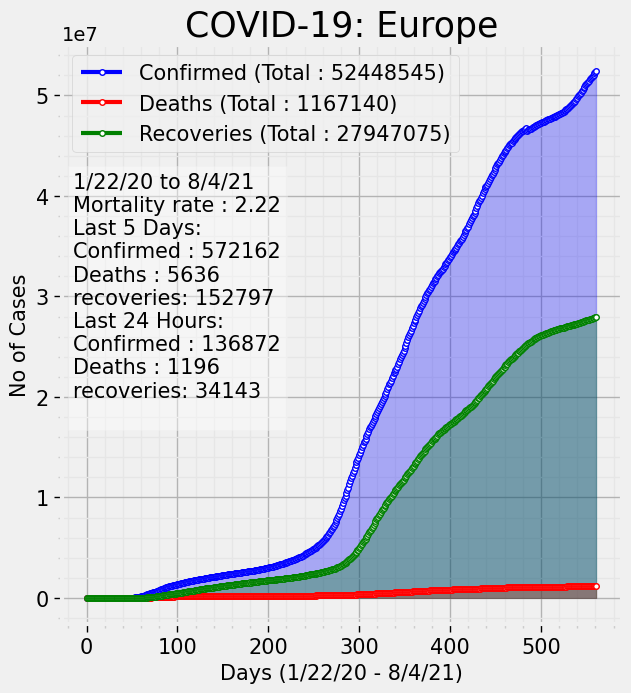

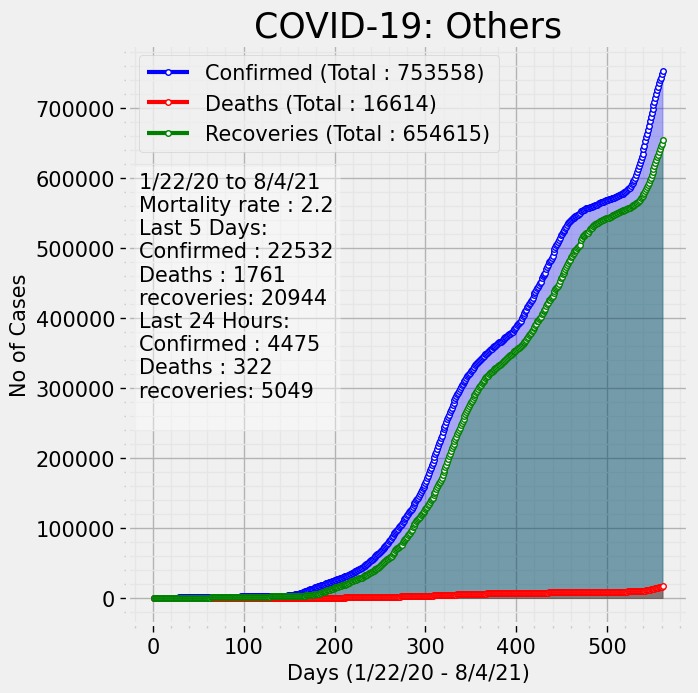

In [32]:
#Nhập mã lập trình của bạn tại đây:
for x in continents.values():
    visualize_covid_cases_2(confirmed_df,deaths_df,recoveries_df,continent=x)

# Bài toán 12
    Trực quan hóa ma trận tương quan của continents_df.

                Confirmed    Deaths  Recoveries    Active  Mortality Rate
Confirmed        1.000000  0.914620    0.826761  0.525919       -0.105117
Deaths           0.914620  1.000000    0.690083  0.575431        0.251685
Recoveries       0.826761  0.690083    1.000000 -0.043594       -0.138545
Active           0.525919  0.575431   -0.043594  1.000000        0.010406
Mortality Rate  -0.105117  0.251685   -0.138545  0.010406        1.000000


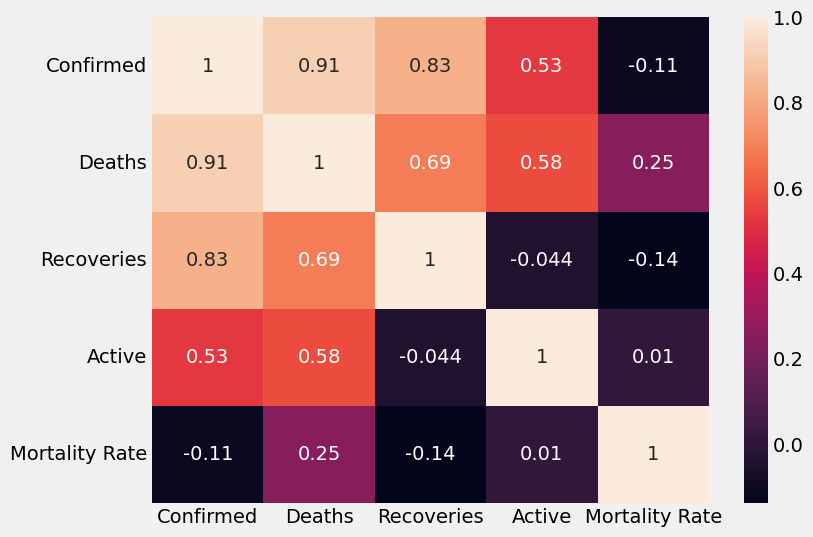

In [33]:
cov_matrix= np.cov(continental_df.transpose())
std_v=np.sqrt(np.diag(cov_matrix))
correla_matrix=pd.DataFrame(cov_matrix/(np.outer(std_v,std_v)))
correla_matrix.columns=continental_df.columns
correla_matrix.index=continental_df.columns
print(correla_matrix)
plt.figure(figsize=(8, 6)) 
sns.heatmap(correla_matrix, annot=True)
plt.show()

# Bài toán 13
    Xây dựng biểu đồ hình tròn để so sánh tỷ lệ số ca dương tính, số người chết, số người khỏi bệnh và đang điều trị của 7 lục địa.
    Mỗi trường (xác nhận, tử vong, ...) nên được trình bày trong các biểu đồ hình tròn khác nhau.
    Bạn không được phép sử dụng đoạn mã lặp lại ở đây, hãy thử sử dụng vòng lặp for.
    Mỗi lục địa nên được trình bày bằng các màu sắc khác nhau.

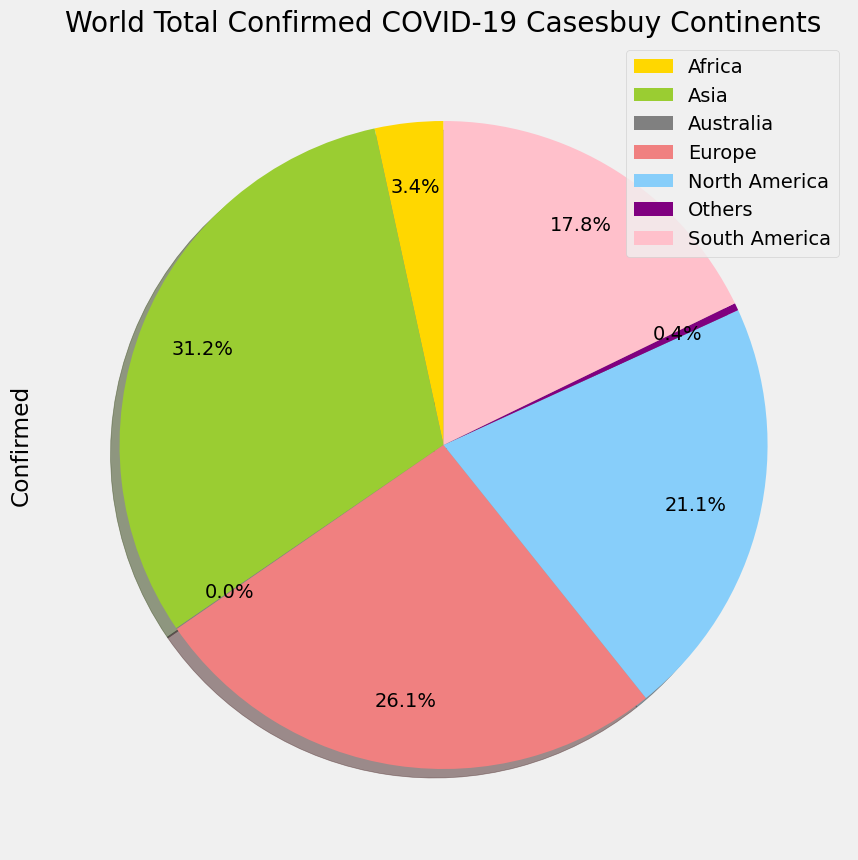

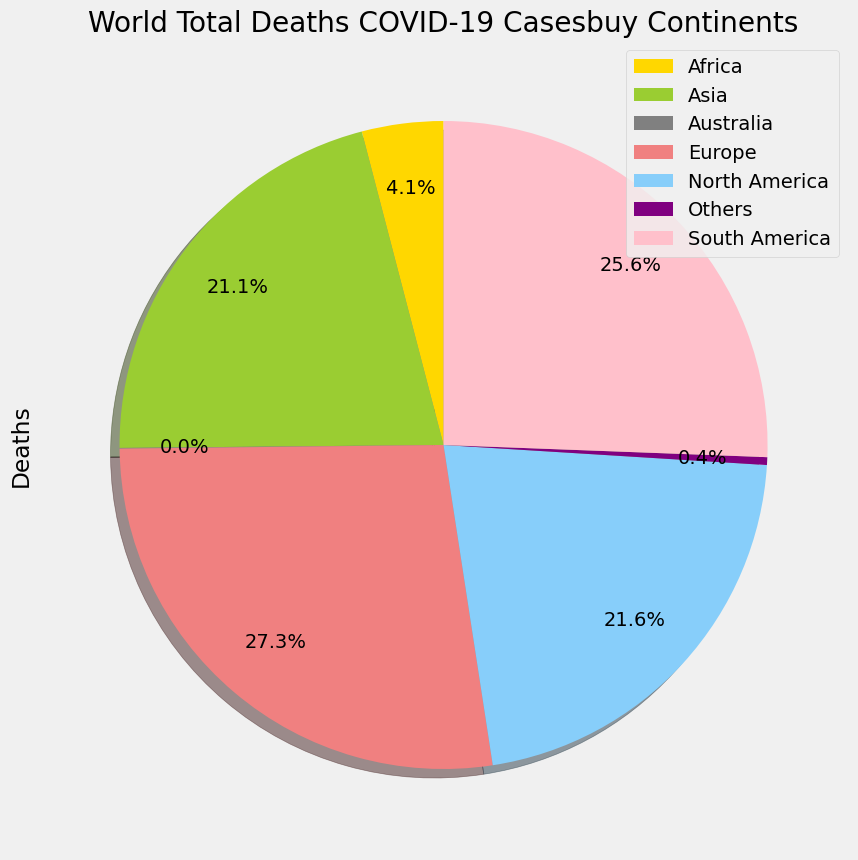

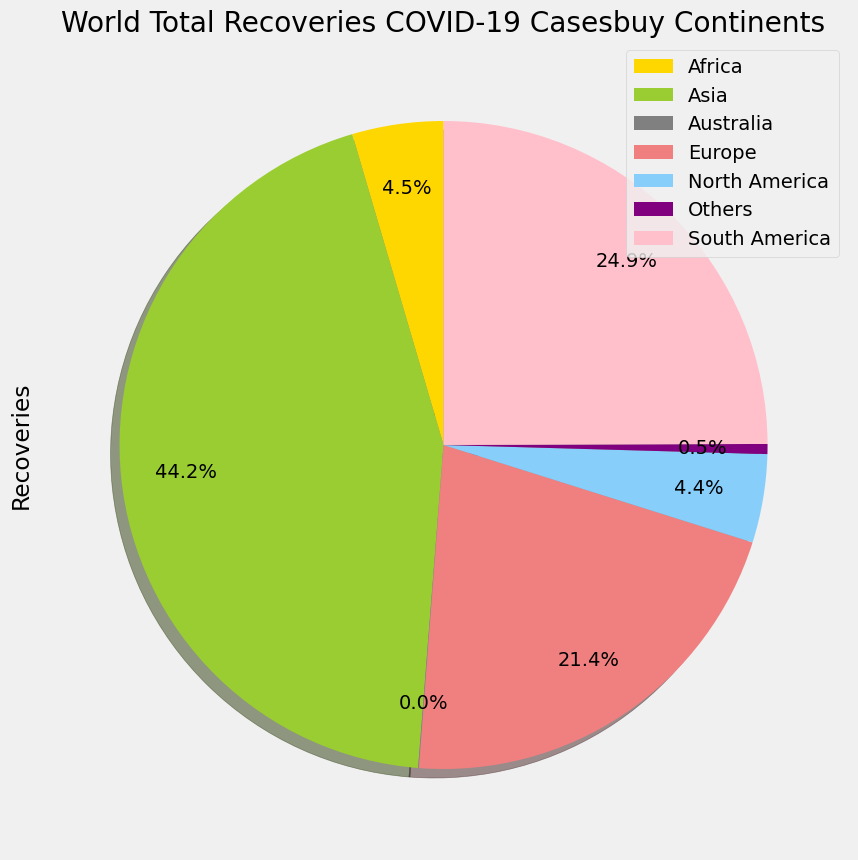

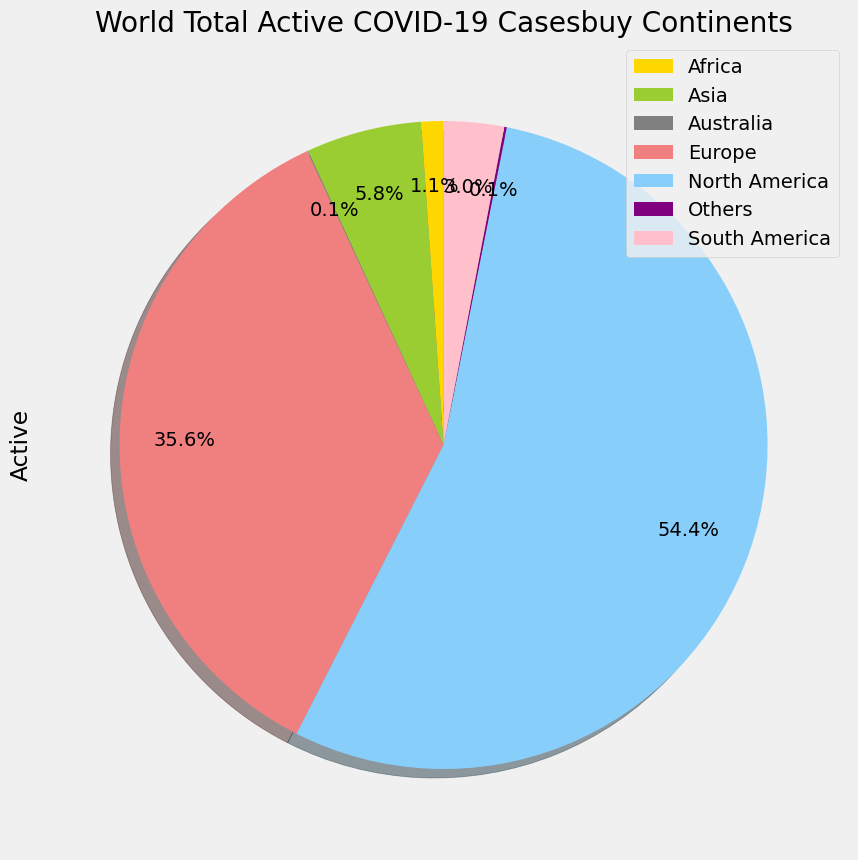

In [34]:
for x in continental_df.columns[0:4]:
    plt.figure(figsize=(16, 32))
    continental_df[x].plot(kind='pie'
                           ,figsize=(20,10)
                           ,startangle = 90,
                           colors=['gold', 'yellowgreen', 'gray','lightcoral','lightskyblue', 'purple', 'pink'],#['gray','yellow','purple','green','red','black','blue'],
                           labels= None,
                           autopct='%1.1F%%',
                           pctdistance = 0.8,
                           shadow = True,
                           #explode =[0.1,0.1,0.1,0.1,0.1,0.1,0.1]
                          )
    plt.legend(labels=continental_df.index, loc='upper right')
    plt.title('World Total ' + x + ' COVID-19 Casesbuy Continents')
    plt.show()

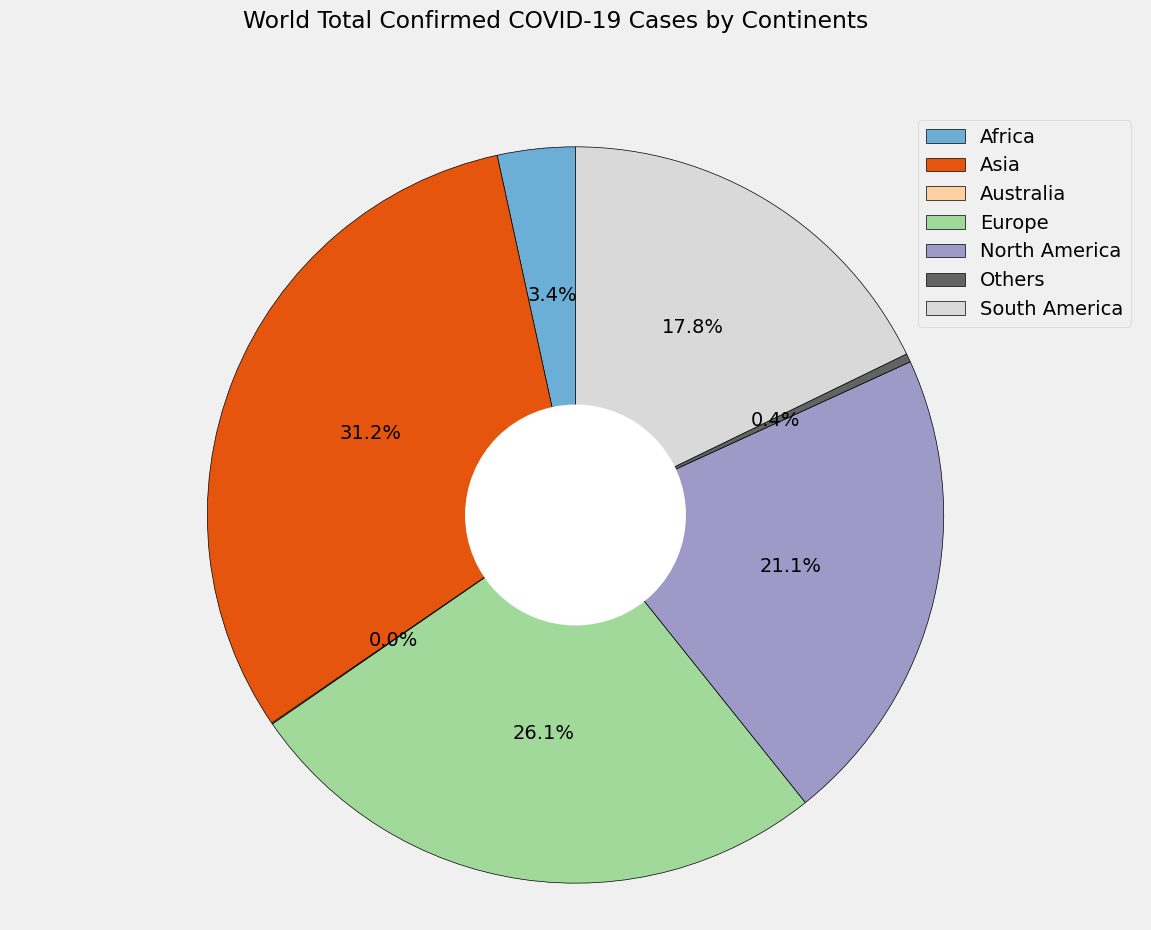

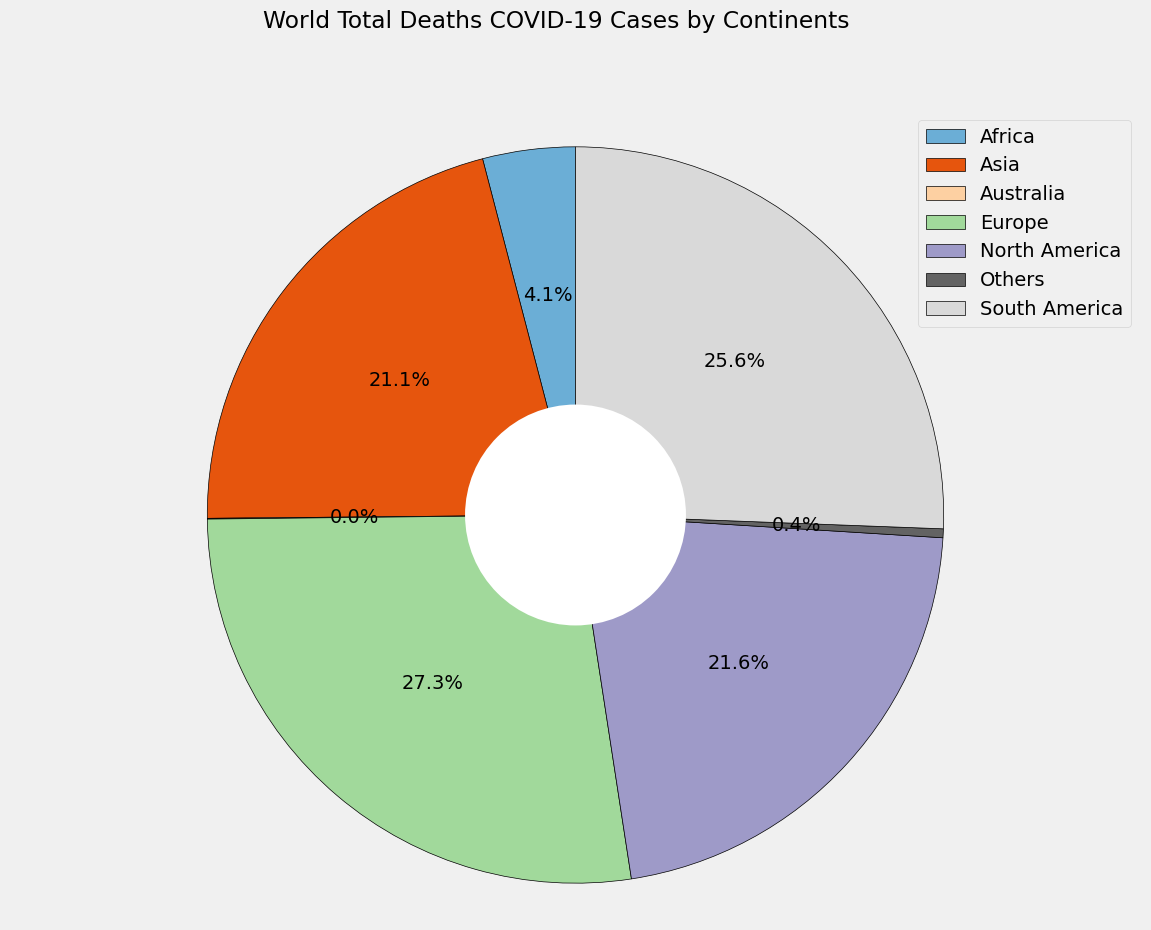

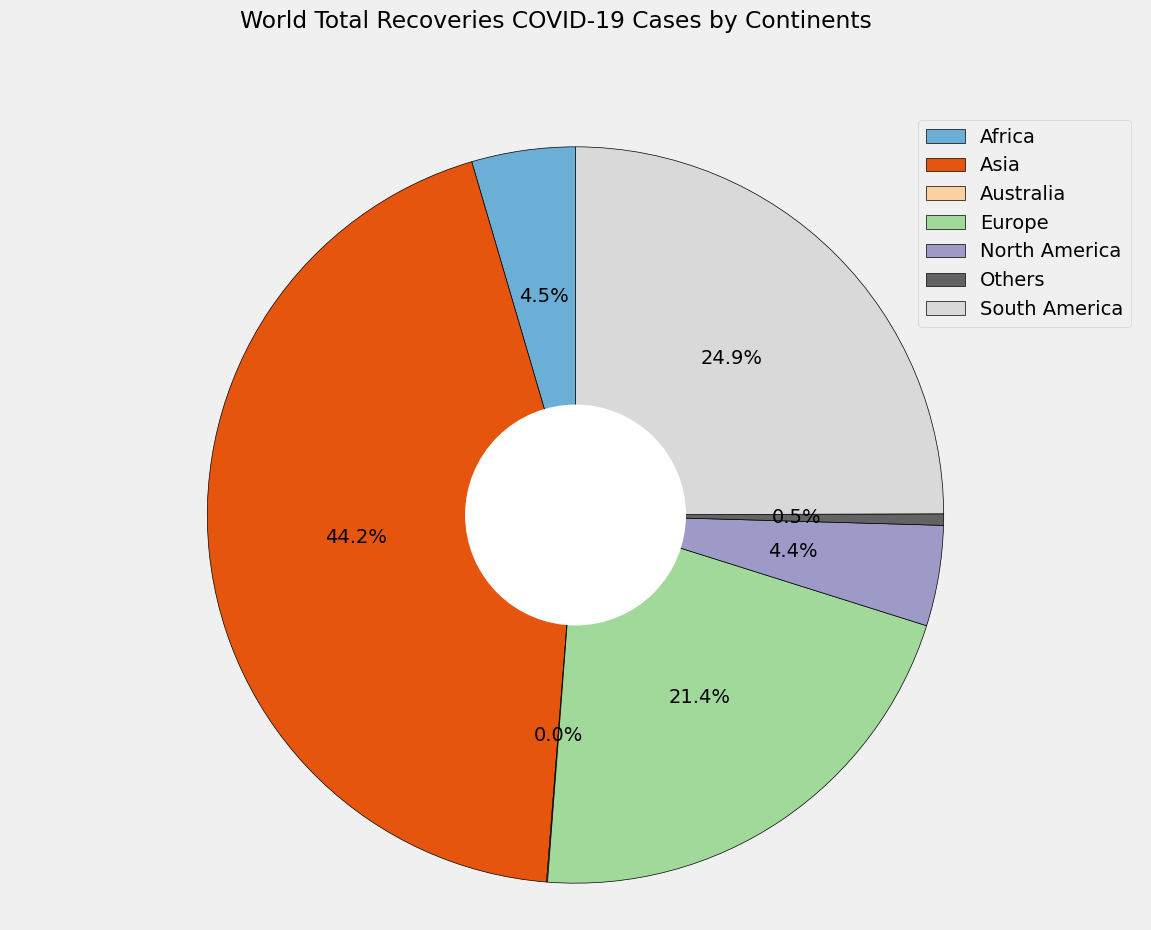

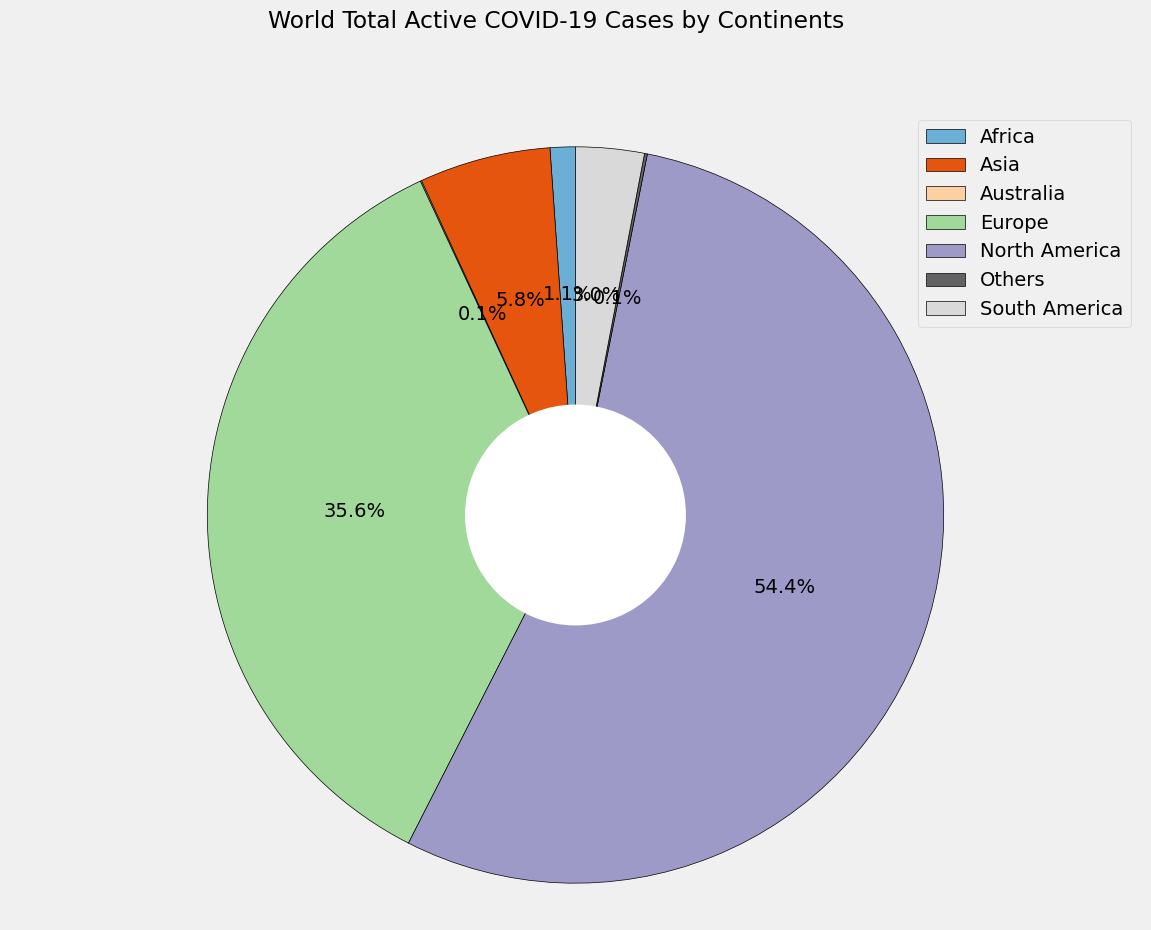

In [ ]:
#Nhập mã lập trình của bạn tại đây: World Total Confirmed COVID-19 Casesbuy Continents


# 6. Phân tích theo quốc gia

# Bài toán 14
    Xây dựng bản đồ folium để hiển thị số người được xác nhận, tử vong, phục hồi và tỷ lệ tử vong của mỗi quốc gia dựa trên vị trí của các quốc gia. Bán kính của hình tròn tỷ lệ thuận với số lượng xác nhận.
![title](problem14.png)

In [35]:
df_14=confirmed_df.loc[:,['Country/Region','Lat','Long']].groupby('Country/Region').first()
df_14=df_14.join(country_df)
df_14.rename(columns={'Mortality Rate': 'Mortality_Rate'}, inplace=True)  
df_14=df_14.reset_index()
df_14.rename(columns={'Country/Region': 'Country'}, inplace=True)  
df_14.head()

,Country,Lat,Long,continent,Confirmed,Deaths,Recoveries,Active,Mortality_Rate
0,Afghanistan,33.93911,67.709953,Asia,148933,6836,82586,59511,4.589983
1,Albania,41.15330,20.168300,Europe,133310,2457,130314,539,1.843073
2,Algeria,28.03390,1.659600,Africa,176724,4404,118409,53911,2.492021
3,Andorra,42.50630,1.521800,Europe,14797,128,14380,289,0.865040
4,Angola,-11.20270,17.873900,Africa,43158,1026,39582,2550,2.377311


In [36]:
#code chính thức bài 14
m=folium.Map(zoom_start=2)
# Giả định df_14 và m đã được định nghĩa trước đó  
for c in df_14.itertuples():  
    folium.Circle(  
        location=(c.Lat, c.Long),  
        radius=c.Confirmed *0.1,  
        color='orange',  
        fill=True,  # Thay 'full' thành 'fill' cho đúng cú pháp  
        fill_color='orange',  
        popup=(f"<div style='text-align: center;'>"  # Canh giữa toàn bộ nội dung  
               f"<strong>USA</strong><br>"  # Chỉ canh giữa chữ "USA"  
               f"</div>"  # In đậm tên quốc gia   "  
               f'Confirmed: {c.Confirmed}<br>'  
               f'Deaths: {c.Deaths}<br>'  
               f'Recovered: {c.Recoveries}<br>'  
               f'Mortality Rate: {getattr(c, "Mortality_Rate", 0):.2f}%')   
    ).add_to(m)  
m

# Bài toán 15
Xây dựng một bản đồ px [(plotly.express)](https://plotly.com/python/plotly-express/) để hiển thị số lượng hoạt động của mỗi quốc gia trong log(10) dựa trên tên của các quốc gia bằng cách sử dụng màu "spectral" (quang phổ).

In [38]:
df_15=df_14.copy()
df_15['Log10_Active']= np.log10(df_14['Active'])
df_15

C:\Users\thaoq\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

C:\Users\thaoq\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log10



,Country,Lat,Long,continent,Confirmed,Deaths,Recoveries,Active,Mortality_Rate,Log10_Active
0,Afghanistan,33.939110,67.709953,Asia,148933,6836,82586,59511,4.589983,4.774597
1,Albania,41.153300,20.168300,Europe,133310,2457,130314,539,1.843073,2.731589
2,Algeria,28.033900,1.659600,Africa,176724,4404,118409,53911,2.492021,4.731677
3,Andorra,42.506300,1.521800,Europe,14797,128,14380,289,0.865040,2.460898
4,Angola,-11.202700,17.873900,Africa,43158,1026,39582,2550,2.377311,3.406540
...,...,...,...,...,...,...,...,...,...,...
196,West Bank and Gaza,31.952200,35.233200,Others,317404,3609,312320,1475,1.137037,3.168792
197,Winter Olympics 2022,39.904200,116.407400,Others,0,0,0,0,NaN,-inf
198,Yemen,15.552727,48.516388,Asia,7096,1380,4251,1465,19.447576,3.165838
199,Zambia,-13.133897,27.849332,Africa,197791,3430,189658,4703,1.734154,3.672375


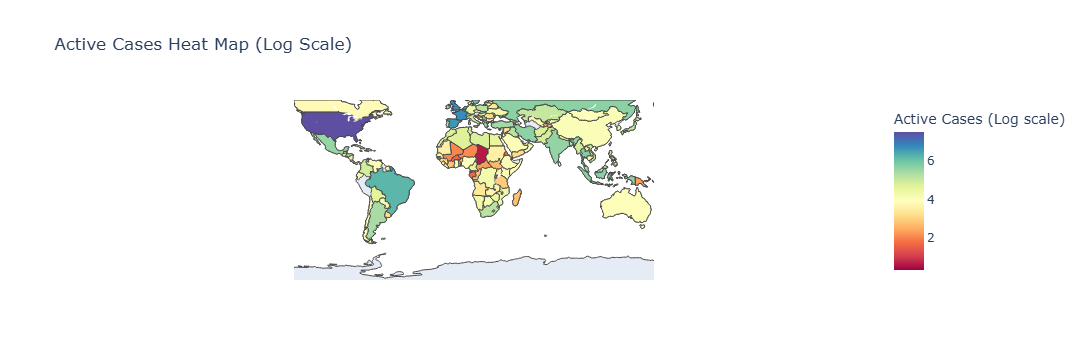

In [39]:
fig_15 = px.choropleth(df_15,  
                    locations='Country',   
                    locationmode='country names',   
                    color='Log10_Active',  
                    color_continuous_scale='spectral',  
                    title='Active Cases Heat Map (Log Scale)',  
                    labels={'Log10_Active': 'Active Cases (Log scale)'} ,
                    hover_name='Country',
                    hover_data={'Country': True,'Active': True,'Log10_Active': True}     
                    )  
fig_15.update_layout(geo=dict(showframe=False))  
# Hiện thị bản đồ  
fig_15.show()  

# Bài toán 16
    Lọc 10 quốc gia hàng đầu dựa trên số ca dương tính.

In [40]:
df_16=df_14.sort_values('Confirmed',ascending=False).head(10)
df_16.set_index('Country',inplace=True)
df_16

,Lat,Long,continent,Confirmed,Deaths,Recoveries,Active,Mortality_Rate
Country,,,,,,,,
USA,40.000000,-100.000000,North America,35460776,611222,0,34849554,1.723657
India,20.593684,78.962880,Asia,31812114,426290,30974748,411076,1.340024
Brazil,-14.235000,-51.925300,South America,20034407,559944,17771228,1703235,2.794912
Russia,61.524010,105.318756,Europe,6274006,159032,5609682,505292,2.534776
France,3.933900,-53.125800,Europe,6272466,112245,415111,5745110,1.789488
United Kingdom,18.220600,-63.068600,Europe,5980830,157209,24693,5798928,2.628548
Turkey,38.963700,35.243300,Asia,5822487,51767,5478185,292535,0.889087
Argentina,-38.416100,-63.616700,South America,4975616,106747,4615834,253035,2.145403
Colombia,4.570900,-74.297300,South America,4815063,121695,4615354,78014,2.527381


# Bài toán 17
    Trực quan hóa 10 quốc gia hàng đầu đã được xác nhận với số ca đang điều trị, khỏi bệnh và tử vong bằng cách sử dụng biểu đồ cột chồng.
![title](problem17.png)

In [44]:
df_17=df_16.loc[:,['Deaths','Recoveries','Active']].reset_index()
df_17

,Country,Deaths,Recoveries,Active
0,USA,611222,0,34849554
1,India,426290,30974748,411076
2,Brazil,559944,17771228,1703235
3,Russia,159032,5609682,505292
4,France,112245,415111,5745110
5,United Kingdom,157209,24693,5798928
6,Turkey,51767,5478185,292535
7,Argentina,106747,4615834,253035
8,Colombia,121695,4615354,78014
9,Spain,81844,150376,4312964


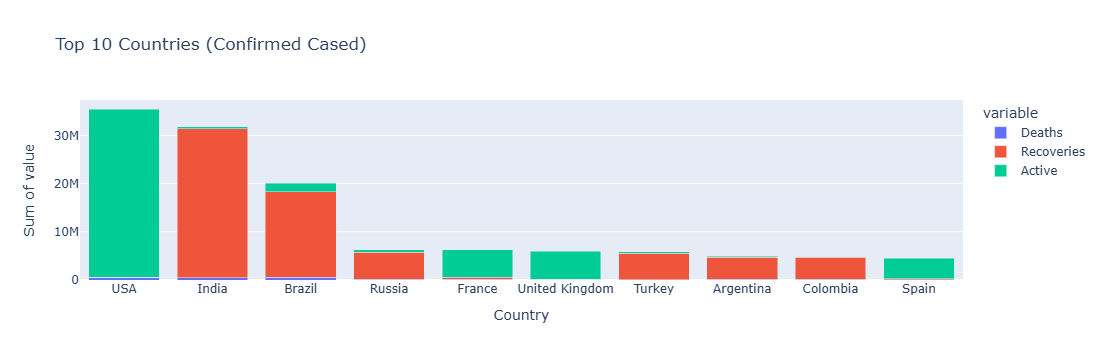

In [45]:
fig_17 = px.bar(df_17,
               x='Country',
               y=list(df_17.columns[1:4]),
               barmode='stack',
               labels = {'value':'Sum of value'},
               title='Top 10 Countries (Confirmed Cased)'
               )
fig_17.show()

# 7. Phân tích nâng cao


# Bài toán 18
    Dựa trên dữ liệu trực quan trên toàn cầu, dịch COVID 2019 trên thế giới đã đạt đến đỉnh điểm chưa?

    Đặt câu trả lời của bạn ở đây:
    - Dựa trên dữ liệu trực quan hóa số lượng gia tăng hàng ngày về tổng số lượng trường hợp mắc COVID-19, cho thấy tình hình dịch COVID 2019 đã đạt đỉnh vào các ngày 4/15/2021 đến 5/5/2021 (tương ứng trong khoảng 450 đến 470)
    - Dựa trên dữ liệu trực quan hóa số lượng gia tăng hàng ngày về tổng số lượng trường hợp tử vong do COVID-19 đã đạt đỉnh vào các ngày 1/5/2021 đến 2/4/2021 (tương ứng trong khoảng 350 đến 380)
    - tỉ lệ tử vong đạt đỉnh khoảng tháng 5 năm 2020 
    - dự đoán xu hướng dữ liệu tăng nhưng không tăng ngặt do có các biện pháp phòng bệnh, vaccin và có các phác đồ điều trị vì thế giảm tỉ lệ tử vong 

# Bài toán 19
Dựa trên trực quan hóa dữ liệu theo quốc gia:

    19.1 Châu lục nào có tỷ lệ tử vong cao nhất so với các trường hợp dương tính của các châu lục?

    19.2 Châu lục nào có tỷ lệ lây lan COVID 2019 cao nhất so với các trường hợp dương tính của các châu lục?
    
    19.3 Châu lục nào có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các lục địa?
Nhập câu trả lời của bạn ở đây:

In [46]:
continental_df['Infection_Rate'] = ((continental_df['Confirmed']/continental_df['Confirmed'].sum())*100)
continental_df['Recovery_Rate']= ((continental_df['Recoveries']/continental_df['Confirmed'])*100)
continental_df

,Confirmed,Deaths,Recoveries,Active,Mortality Rate,Infection_Rate,Recovery_Rate
continent,,,,,,,
Africa,6855602,174000,5955131,726471,2.538070,3.414849,86.865180
Asia,62536726,902952,57853343,3780431,1.443875,31.150212,92.510988
Australia,90000,1425,55290,33285,1.583333,0.044830,61.433333
Europe,52448545,1167140,27947075,23334330,2.225305,26.125181,53.284748
North America,42351963,924518,5776939,35650506,2.182940,21.095966,13.640310
Others,753558,16614,654615,82329,2.204741,0.375355,86.869889
South America,35722194,1096367,32656668,1969159,3.069148,17.793607,91.418427


In [50]:
continental_df.reset_index(inplace=True)
print('19.1 Châu lục có tỷ lệ tử vong cao nhất so với các trường hợp dương tính của các châu lục:\n',
continental_df.sort_values('Mortality Rate',ascending=False).head(1)['continent'].values)
print('19.2 Châu lục có lây lan COVID 2019 cao nhất so với các trường hợp dương tính của các châu lục :\n',
continental_df.sort_values('Infection_Rate',ascending=False).head(1)['continent'].values)
print('19.3 Châu lục có lây lan COVID 2019 cao nhất so với các trường hợp dương tính của các châu lục :\n',
continental_df.sort_values('Recovery_Rate',ascending=False).head(1)['continent'].values)

19.1 Châu lục có tỷ lệ tử vong cao nhất so với các trường hợp dương tính của các châu lục:
 ['South America']
19.2 Châu lục có lây lan COVID 2019 cao nhất so với các trường hợp dương tính của các châu lục :
 ['Asia']
19.3 Châu lục có lây lan COVID 2019 cao nhất so với các trường hợp dương tính của các châu lục :
 ['Asia']


# Bài toán 20
Dựa trên trực quan hóa dữ liệu theo quốc gia:

    20.1Quốc gia nào có tỷ lệ tử vong cao nhất trong tập dữ liệu của các quốc gia?

    20.2 Quốc gia nào có tỷ lệ lan truyền COVID 2019 cao nhất trong tập dữ liệu các quốc gia?
    
    20.3 Quốc gia nào có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các quốc gia?
Nhập câu trả lời của bạn ở đây:

In [47]:
country_df['Infection_Rate'] = ((country_df['Confirmed']/country_df['Confirmed'].sum())*100)
country_df['Recovery_Rate']= ((country_df['Recoveries']/country_df['Confirmed'])*100)
country_df

,continent,Confirmed,Deaths,Recoveries,Active,Mortality Rate,Infection_Rate,Recovery_Rate
Country/Region,,,,,,,,
Afghanistan,Asia,148933,6836,82586,59511,4.589983,0.074185,55.451780
Albania,Europe,133310,2457,130314,539,1.843073,0.066403,97.752607
Algeria,Africa,176724,4404,118409,53911,2.492021,0.088028,67.002218
Andorra,Europe,14797,128,14380,289,0.865040,0.007371,97.181861
Angola,Africa,43158,1026,39582,2550,2.377311,0.021497,91.714167
...,...,...,...,...,...,...,...,...
West Bank and Gaza,Others,317404,3609,312320,1475,1.137037,0.158102,98.398256
Winter Olympics 2022,Others,0,0,0,0,NaN,0.000000,NaN
Yemen,Asia,7096,1380,4251,1465,19.447576,0.003535,59.906990


In [48]:
country_df.reset_index(inplace=True)
print('20.1 Quốc gia có tỷ lệ tử vong cao nhất trong tập dữ liệu của các quốc gia:\n',
country_df.sort_values('Mortality Rate',ascending=False).head(1)['Country/Region'].values)
print('20.2 Quốc gia có tỷ lệ lan truyền COVID 2019 cao nhất trong tập dữ liệu các quốc gia:\n',
country_df.sort_values('Infection_Rate',ascending=False).head(1)['Country/Region'].values)
print('20.3 Quốc gia có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các quốc gia\n',
country_df.sort_values('Recovery_Rate',ascending=False).head(1)['Country/Region'].values)

20.1 Quốc gia có tỷ lệ tử vong cao nhất trong tập dữ liệu của các quốc gia:
 ['Vanuatu']
20.2 Quốc gia có tỷ lệ lan truyền COVID 2019 cao nhất trong tập dữ liệu các quốc gia:
 ['USA']
20.3 Quốc gia có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các quốc gia
 ['Samoa']


# Bài toán 21
**Tập dữ liệu USA**

In [52]:
us_medical_data = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports_us/07-06-2020.csv')

Dựa trên dữ liệu của Mỹ:

    21.1 Tiểu bang nào có tỷ lệ tử vong cao nhất trong tập dữ liệu của các tiểu bang?
    21.2 Tiểu bang nào có tỷ lệ lan truyền COVID 2019 cao nhất trong tập dữ liệu của các tiểu bang?
    21.3 Tiểu bang nào có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các tiểu bang?

In [53]:
#Nhập mã lập trình của bạn tại đây:
us_medical_data['Recovery_Rate'] = ((us_medical_data['Recovered']/us_medical_data['Confirmed'])*100)
print('21.1 Tiểu bang có tỷ lệ tử vong cao nhất trong tập dữ liệu của các tiểu bang:\n',
us_medical_data.sort_values('Mortality_Rate',ascending=False).head(1)['Province_State'].values)
print('21.2 Tiểu bang có tỷ lệ lan truyền COVID 2019 cao nhất trong tập dữ liệu các tiểu bang:\n',
us_medical_data.sort_values('Incident_Rate',ascending=False).head(1)['Province_State'].values)
print('21.3 Tiểu bang có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các tiểu bang\n',
us_medical_data.sort_values('Recovery_Rate',ascending=False).head(1)['Province_State'].values)


21.1 Tiểu bang có tỷ lệ tử vong cao nhất trong tập dữ liệu của các tiểu bang:
 ['Connecticut']
21.2 Tiểu bang có tỷ lệ lan truyền COVID 2019 cao nhất trong tập dữ liệu các tiểu bang:
 ['New York']
21.3 Tiểu bang có tỷ lệ khỏi bệnh cao nhất trong tập dữ liệu của các tiểu bang
 ['Minnesota']


# Bài toán 22
Xây dựng mô hình hồi quy (hoặc nhiều hơn 1 mô hình) để dự đoán số trường hợp Deaths trong các bang New York, Florida, Texas, California tại Hoa Kỳ dựa trên số ca Confirmed. Điều này có nghĩa sẽ sử dụng dữ liệu của các bang còn lại để làm bộ data train mô hình và sử dụng dữ liệu của 4 bang New York, Florida, Texas, California để làm bộ test cho mô hình

In [57]:
us_medical_data.set_index('Province_State',inplace=True)
print(us_medical_data.index)
train=['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas',
        'Colorado', 'Connecticut', 'Delaware', 'Diamond Princess',
       'District of Columbia','Georgia', 'Grand Princess', 'Guam',
       'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
       'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
       'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'North Carolina', 'North Dakota', 'Northern Mariana Islands', 'Ohio',
       'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island',
       'South Carolina', 'South Dakota', 'Tennessee', 'Utah',
       'Vermont', 'Virgin Islands', 'Virginia', 'Washington', 'West Virginia',
       'Wisconsin', 'Wyoming']
test=['New York','Florida', 'Texas', 'California']
print(train,'\n',test)
TRAIN=us_medical_data.loc[train,['Confirmed','Deaths']]
# dữ liệu train
#plt.figure(figsize=(10,6))
#tr_=sns.regplot(x=TRAIN['Confirmed'],y=TRAIN['Deaths'])
#tr_.set_title('Sơ đồ phân tán tập dữ liệu train và mô hình hồi quy dự đoán')
TEST =us_medical_data.loc[test,['Confirmed','Deaths']]


Index(['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas',
       'California', 'Colorado', 'Connecticut', 'Delaware', 'Diamond Princess',
       'District of Columbia', 'Florida', 'Georgia', 'Grand Princess', 'Guam',
       'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
       'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
       'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Northern Mariana Islands', 'Ohio',
       'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island',
       'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah',
       'Vermont', 'Virgin Islands', 'Virginia', 'Washington', 'West Virginia',
       'Wisconsin', 'Wyoming'],
      dtype='object', name='Province_State')
['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware

Hệ số sau khi train bậc 1 [ 6.07651354e-02 -5.20672576e+02]
Hệ số sau khi train bậc 2 [3.31133727e-07 1.73806703e-02 8.75668334e+01]
Hệ số sau khi train bậc 3 [ 2.76646872e-12 -3.06595485e-07  5.05147580e-02 -1.41789275e+02]
                Confirmed  Deaths  DEaths_Predict_1  DEaths_Predict_2  \
Province_State                                                          
New York           397649   32057      23642.522767      59359.403294   
Florida            206447    3778      12024.107340      17788.793997   
Texas              204710    2891      11918.558300      17522.114784   
California         284348    6369      16757.772156      31803.140896   

                DEaths_Predict_3  
Province_State                    
New York           145415.433060  
Florida             21561.352799  
Texas               21083.309934  
California          53035.384950  


,Confirmed,Deaths,DEaths_Predict_1,DEaths_Predict_2,DEaths_Predict_3
count,4.000000,4.000000,4.000000,4.000000,4.000000
mean,273288.500000,11273.750000,16085.740141,31618.363243,60273.870186
std,90845.369144,13933.853484,5520.231160,19660.117430,58697.076624
min,204710.000000,2891.000000,11918.558300,17522.114784,21083.309934
25%,206012.750000,3556.250000,11997.720080,17722.124194,21441.842083
50%,245397.500000,5073.500000,14390.939748,24795.967446,37298.368874
75%,312673.250000,12791.000000,18478.959809,38692.206495,76130.396978
max,397649.000000,32057.000000,23642.522767,59359.403294,145415.433060


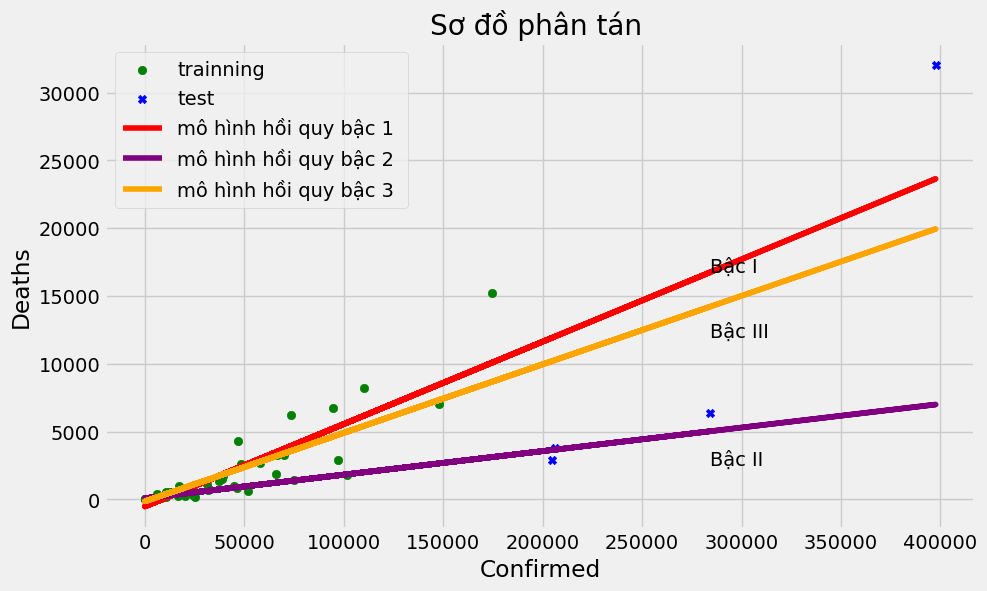

In [63]:
#Nhập mã lập trình của bạn tại đây:
plt.figure(figsize=(10,6))
#vẽ scatter của bộ dữ liệu
plt.scatter(TRAIN['Confirmed'],TRAIN['Deaths'],label='trainning',color='green',marker='o')
plt.scatter(TEST['Confirmed'],TEST['Deaths'],label='test',color='blue',marker='X')
plt.xlabel('Confirmed')
plt.ylabel('Deaths')
plt.title('Sơ đồ phân tán ')
#Tìm hệ số mô hình hồi quy bậc 1
xtr=TRAIN['Confirmed']
ytr=TRAIN['Deaths']
f = np.polyfit(xtr,ytr,deg = 1)
print('Hệ số sau khi train bậc 1',f)

#thêm cột 'DEaths_Predict' vào bộ dữ liệu text đựa theo hệ số mô hình hồi quy bậc 1
TEST['DEaths_Predict_1']=f[0]*TEST['Confirmed']+f[1]

#Vẽ đường thẳng mô hình hồi quy bậc 1 tren toàn bộ dữ liệu
x=us_medical_data['Confirmed']#TEST['Confirmed']
plt.plot(x, f[0]*x+f[1], color='red',label= 'mô hình hồi quy bậc 1',)
plt.annotate('Bậc I', xy = (284348,16757))#'y={0:.2f}x+{1:.2f}'.format(f[0],f[1]), xy = (284348,16757))

#Tìm hệ số mô hình hồi quy bậc 2
f = np.polyfit(xtr,ytr,deg = 2)
print('Hệ số sau khi train bậc 2',f,)

#thêm cột 'DEaths_Predict_2' vào bộ dữ liệu text đựa theo hệ số mô hình hồi quy bậc 2
TEST['DEaths_Predict_2']=f[0]*TEST['Confirmed']**2+f[1]*TEST['Confirmed']+f[2]

#Vẽ đường thẳng mô hình hồi quy bậc 2 tren toàn bộ dữ liệu
plt.plot(x, f[0]*(x^2)+f[1]*x+f[2], color='purple',label= 'mô hình hồi quy bậc 2 ')
plt.annotate('Bậc II',xy = (284348,2500))#'y={0:.7f}x^2+{1:.2f}x+{2:.2f}'.format(f[0],f[1],f[2]), xy = (284348,2500))

#Tìm hệ số mô hình hồi quy bậc 3
f = np.polyfit(xtr,ytr,deg = 3)
print('Hệ số sau khi train bậc 3',f,)

#thêm cột 'DEaths_Predict_2' vào bộ dữ liệu text đựa theo hệ số mô hình hồi quy bậc 2
TEST['DEaths_Predict_3']= f[0]*TEST['Confirmed']**3+f[1]*TEST['Confirmed']**2+f[2]*TEST['Confirmed']+f[3]

#Vẽ đường thẳng mô hình hồi quy bậc 2 tren toàn bộ dữ liệu
plt.plot(x,f[0]*(x^3)+ f[1]*(x^2)+f[2]*x+f[3], color='orange',label= 'mô hình hồi quy bậc 3 ')
plt.annotate('Bậc III',xy = (284348,12000))#'y={0:.7f}x^3+{1:.7f}x^2+{2:.2f}x+{3:.2f}'.format(f[0],f[1],f[2],f[3]), xy = (284348,12000))
plt.legend()
print(TEST)
TEST.describe()
#plt.show()